# Sentiment_analysis

In [242]:
import pandas as pd
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [243]:
#tweet loading
tweets = pd.read_csv("file:///home/chakuunaa/BD_ADA_CA2sem2/data/stocktweet.csv")

tweets.head()

,id,date,ticker,tweet
0,100001,01/01/2020,AMZN,$AMZN Dow futures up by 100 points already 🥳
1,100002,01/01/2020,TSLA,$TSLA Daddy's drinkin' eArly tonight! Here's t...
2,100003,01/01/2020,AAPL,$AAPL We’ll been riding since last December fr...
3,100004,01/01/2020,TSLA,"$TSLA happy new year, 2020, everyone🍷🎉🙏"
4,100005,01/01/2020,TSLA,"$TSLA haha just a collection of greats...""Mars..."


In [244]:
tweets.shape

(10000, 4)

In [245]:
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [246]:
tweets["clean_tweet"] = tweets["tweet"].apply(clean_tweet)

tweets[["tweet", "clean_tweet"]].head()

,tweet,clean_tweet
0,$AMZN Dow futures up by 100 points already 🥳,amzn dow futures up by 100 points already
1,$TSLA Daddy's drinkin' eArly tonight! Here's t...,tsla daddys drinkin early tonight heres to a p...
2,$AAPL We’ll been riding since last December fr...,aapl well been riding since last december from...
3,"$TSLA happy new year, 2020, everyone🍷🎉🙏",tsla happy new year 2020 everyone
4,"$TSLA haha just a collection of greats...""Mars...",tsla haha just a collection of greatsmars rofl...


In [247]:
analyzer = SentimentIntensityAnalyzer()

In [248]:
tweets["sentiment_score"] = tweets["clean_tweet"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

tweets[["ticker", "date", "clean_tweet", "sentiment_score"]].head()

,ticker,date,clean_tweet,sentiment_score
0,AMZN,01/01/2020,amzn dow futures up by 100 points already,0.0000
1,TSLA,01/01/2020,tsla daddys drinkin early tonight heres to a p...,0.0000
2,AAPL,01/01/2020,aapl well been riding since last december from...,0.2732
3,TSLA,01/01/2020,tsla happy new year 2020 everyone,0.5719
4,TSLA,01/01/2020,tsla haha just a collection of greatsmars rofl...,0.7717


In [249]:

def sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

tweets["sentiment_label"] = tweets["sentiment_score"].apply(sentiment_label)

tweets[["sentiment_score", "sentiment_label"]].head()

,sentiment_score,sentiment_label
0,0.0000,neutral
1,0.0000,neutral
2,0.2732,positive
3,0.5719,positive
4,0.7717,positive


In [250]:
daily_sentiment = tweets.groupby(["date", "ticker"]).agg(
    avg_sentiment=("sentiment_score", "mean"),
    tweet_count=("sentiment_score", "count")
).reset_index()

daily_sentiment.head()

,date,ticker,avg_sentiment,tweet_count
0,01/01/2020,AAPL,0.273200,1
1,01/01/2020,AMZN,0.000000,1
2,01/01/2020,TSLA,0.111975,4
3,01/02/2020,AAPL,0.261133,3
4,01/02/2020,AMZN,0.549900,1


In [251]:
daily_sentiment.groupby("ticker")["avg_sentiment"].mean().sort_values(ascending=False).head(10)

ticker
MA      0.327625
PYPL    0.227606
MCD     0.203543
HD      0.195737
SBUX    0.187796
NKE     0.184058
JNJ     0.167395
AMZN    0.155989
XOM     0.149006
V       0.145305
Name: avg_sentiment, dtype: float64

In [252]:
daily_sentiment.to_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/daily_sentiment.csv",
    index=False
)

tweets.to_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/tweets_with_sentiment.csv",
    index=False
)

In [253]:
import os

os.listdir("/home/chakuunaa/BD_ADA_CA2sem2/data")[:20]

['five_company_model_comparison.csv',
 'stockprice',
 'aapl_features.csv',
 'goog_features.csv',
 'daily_sentiment.csv',
 'stocktweet.csv',
 'tsla_features.csv',
 'arima_forecast_results.csv',
 'processed_tweet_counts',
 'five_company_forecast_1_3_5_days.csv',
 'all_company_forecasts.csv',
 'amzn_features.csv',
 'tweets_with_sentiment.csv',
 'msft_features.csv']

# Feature_engineering

In [256]:
import pandas as pd

In [257]:
sentiment = pd.read_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/daily_sentiment.csv"
)

sentiment.head()

,date,ticker,avg_sentiment,tweet_count
0,01/01/2020,AAPL,0.273200,1
1,01/01/2020,AMZN,0.000000,1
2,01/01/2020,TSLA,0.111975,4
3,01/02/2020,AAPL,0.261133,3
4,01/02/2020,AMZN,0.549900,1


In [258]:
aapl = pd.read_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/stockprice/AAPL.csv"
)

aapl.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600
1,2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400
2,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800
3,2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200
4,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000


In [259]:
aapl["Date"] = pd.to_datetime(aapl["Date"], dayfirst=True, errors="coerce")

sentiment["date"] = pd.to_datetime(sentiment["date"], dayfirst=True, errors="coerce")

In [260]:
aapl[["Date"]].head()

,Date
0,2019-12-31
1,2020-01-02
2,2020-01-03
3,2020-01-06
4,2020-01-07


In [261]:
sentiment[["date"]].head()

,date
0,2020-01-01
1,2020-01-01
2,2020-01-01
3,2020-02-01
4,2020-02-01


In [262]:
aapl_sentiment = sentiment[
    sentiment["ticker"] == "AAPL"
]

In [263]:
merged_aapl = pd.merge(
    aapl,
    aapl_sentiment,
    left_on="Date",
    right_on="date",
    how="left"
)

merged_aapl.head()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
0,2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaT,NaN,NaN,NaN
1,2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
3,2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
4,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


In [264]:
merged_aapl["avg_sentiment"] = merged_aapl[
    "avg_sentiment"
].fillna(0)

In [265]:
features = merged_aapl[
    [
        "Date",
        "Close",
        "Volume",
        "avg_sentiment",
        "tweet_count"
    ]
]

features.head()

,Date,Close,Volume,avg_sentiment,tweet_count
0,2019-12-31,73.412498,100805600,0.000000,NaN
1,2020-01-02,75.087502,135480400,0.376125,8.0
2,2020-01-03,74.357498,146322800,0.103833,6.0
3,2020-01-06,74.949997,118387200,0.779300,2.0
4,2020-01-07,74.597504,108872000,0.069367,3.0


In [266]:
features.to_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv",
    index=False
)

In [267]:
companies = [
    "AAPL",
    "TSLA",
    "AMZN",
    "MSFT",
    "GOOG"
]

In [268]:
for company in companies:

    stock = pd.read_csv(
        f"/home/chakuunaa/BD_ADA_CA2sem2/data/stockprice/{company}.csv"
    )

    stock["Date"] = pd.to_datetime(stock["Date"])

    company_sentiment = sentiment[
        sentiment["ticker"] == company
    ]

    merged = pd.merge(
        stock,
        company_sentiment,
        left_on="Date",
        right_on="date",
        how="left"
    )

    merged["avg_sentiment"] = merged[
        "avg_sentiment"
    ].fillna(0)

    merged.to_csv(
        f"/home/chakuunaa/BD_ADA_CA2sem2/data/{company.lower()}_features.csv",
        index=False
    )

print("Feature engineering complete")

Feature engineering complete


In [269]:
import os

[x for x in os.listdir("/home/chakuunaa/BD_ADA_CA2sem2/data") if "features" in x]

['aapl_features.csv',
 'goog_features.csv',
 'tsla_features.csv',
 'amzn_features.csv',
 'msft_features.csv']

# ARIMA_forecasting

In [270]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [271]:
df=pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv')

In [272]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
0,2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaN,NaN,0.000000,NaN
1,2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
3,2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
4,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


In [273]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
249,2020-12-24,131.320007,133.460007,131.100006,131.970001,129.679718,54930100,2020-12-24,AAPL,-0.128000,1.0
250,2020-12-28,133.990005,137.339996,133.509995,136.690002,134.317825,124486200,2020-12-28,AAPL,0.288850,2.0
251,2020-12-29,138.050003,138.789993,134.339996,134.869995,132.529404,121047300,2020-12-29,AAPL,0.000000,2.0
252,2020-12-30,135.580002,135.990005,133.399994,133.720001,131.399368,96452100,2020-12-30,AAPL,0.000000,1.0
253,2020-12-31,134.080002,134.740005,131.720001,132.690002,130.387222,99116600,2020-12-31,AAPL,0.076167,3.0


In [274]:
## Cleaning up the data
df = df[["Date", "Close"]]

df.head()

,Date,Close
0,2019-12-31,73.412498
1,2020-01-02,75.087502
2,2020-01-03,74.357498
3,2020-01-06,74.949997
4,2020-01-07,74.597504


In [275]:
df.set_index('Date',inplace=True)

In [276]:
df.head()

,Close
Date,
2019-12-31,73.412498
2020-01-02,75.087502
2020-01-03,74.357498
2020-01-06,74.949997
2020-01-07,74.597504


In [277]:
df.describe()

,Close
count,254.000000
mean,95.260718
std,21.810137
min,56.092499
25%,77.379377
50%,91.421249
75%,115.739374
max,136.690002


## Step 2: Visualize the Data

<Axes: xlabel='Date'>

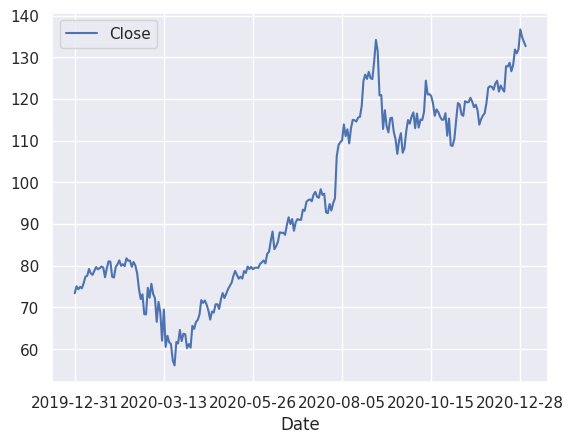

In [278]:
df.plot()

In [ ]:
#import sys
#!{sys.executable} -m pip install statsmodels

In [279]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [280]:
test_result=adfuller(df['Close'])

In [281]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


In [282]:
adfuller_test(df['Close'])

ADF Test Statistic : -0.12702885454878415
p-value : 0.9466789170863883
#Lags Used : 1
Number of Observations Used : 252
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


# Volatility_analysis

In [283]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

In [284]:
# Import as Dataframe
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'])
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
0,2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaN,NaN,0.000000,NaN
1,2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
3,2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
4,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


In [285]:
ser = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')
ser.head()

,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
Date,,,,,,,,,,
2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaN,NaN,0.000000,NaN
2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


## Visualizing a time series
Let’s use matplotlib to visualise the series.

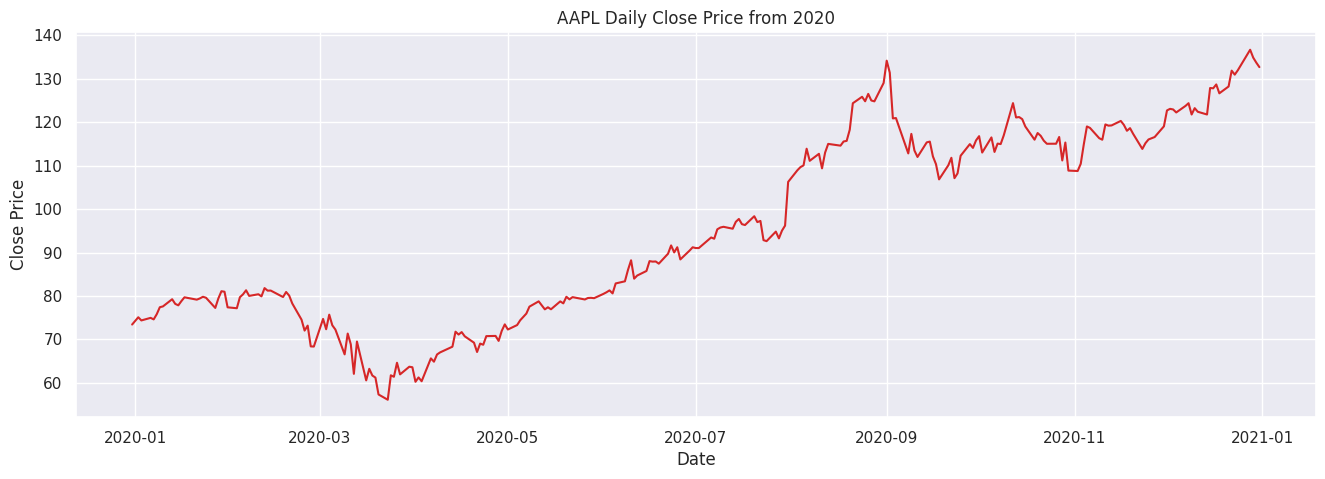

In [286]:
# Time series data source: fpp pacakge data.
import matplotlib.pyplot as plt
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')

# Draw Plot
def plot_df(df, x, y, title="", xlabel='date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df.index, y=df['Close'], title='AAPL Daily Close Price from 2020',
            xlabel='Date',  ylabel='Close Price')    

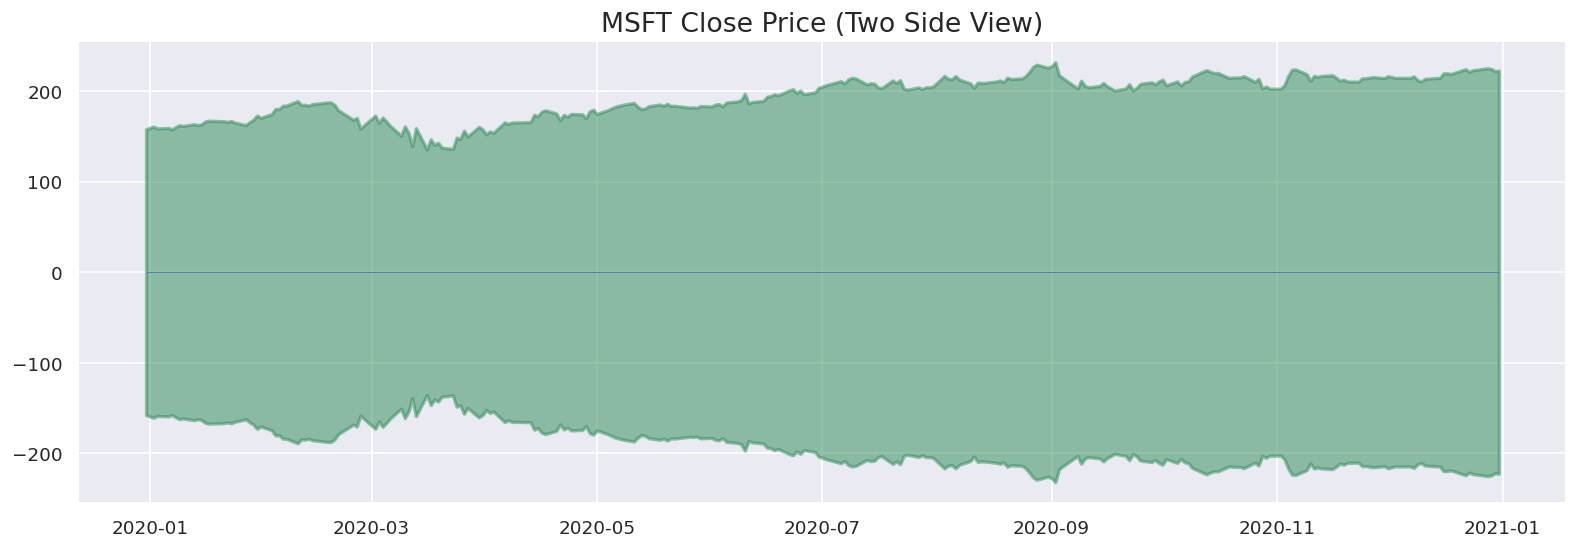

In [287]:
# Import data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv', parse_dates=['Date'])
x = df['Date'].values
y1 = df['Close'].values

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5), dpi= 120)
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='seagreen')

plt.title('MSFT Close Price (Two Side View)', fontsize=16)
plt.hlines(y=0, xmin=np.min(df.Date), xmax=np.max(df.Date), linewidth=.5)
plt.show()

Seasonal Plot of a Time Series

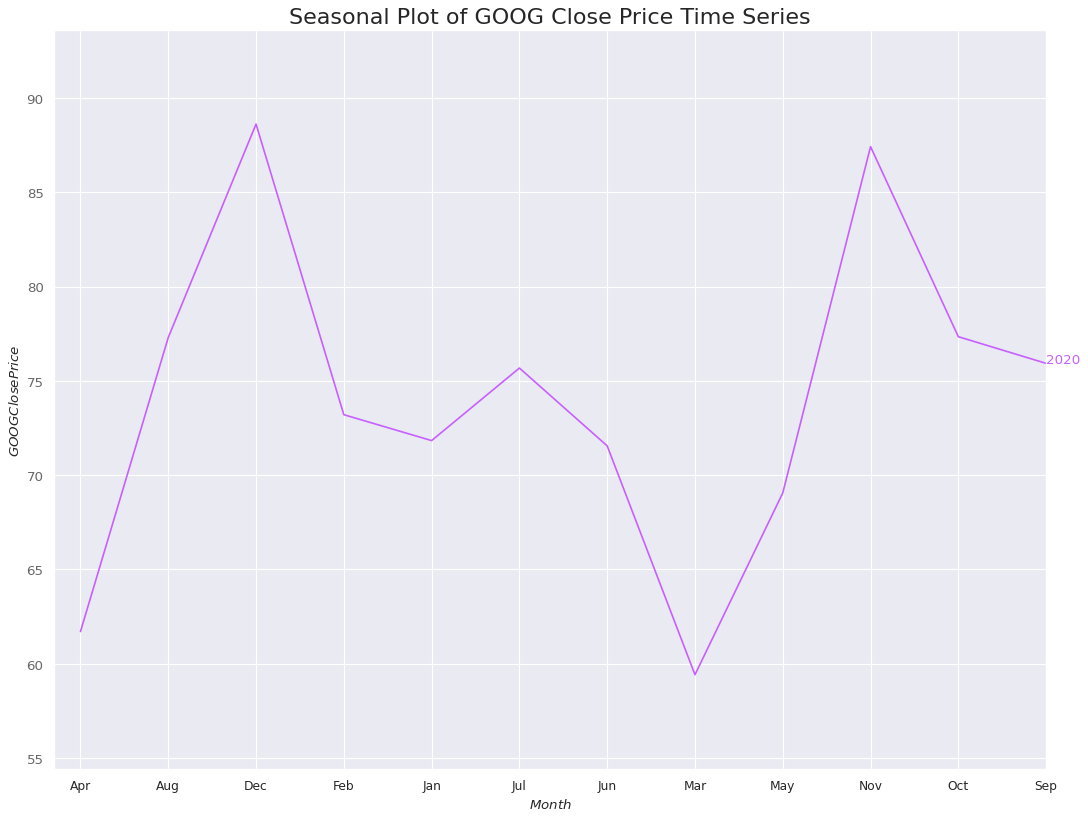

In [288]:
# Import Data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/goog_features.csv', parse_dates=['Date'], index_col='Date')
df.reset_index(inplace=True)

# Prepare data
df['year'] = [d.year for d in df['Date']]
df['month'] = [d.strftime('%b') for d in df['Date']]

df = df.groupby(['year', 'month'])['Close'].mean().reset_index()

years = df['year'].unique()

# Prep Colors
np.random.seed(100)
mycolors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(years), replace=False)

# Draw Plot
plt.figure(figsize=(16,12), dpi= 80)

for i, y in enumerate(years):
    if i > 0:
       plt.plot('month', 'Close', data=df.loc[df.year==y, :], color=mycolors[i], label=y)
       plt.text(11, df.loc[df.year==y, 'Close'].iloc[-1], y, fontsize=12, color=mycolors[i])

# Decoration
plt.gca().set(xlim=(-0.3, 11), ylabel='$GOOG Close Price$', xlabel='$Month$')
plt.ylim(df['Close'].min()-5, df['Close'].max()+5)
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot of GOOG Close Price Time Series", fontsize=20)
plt.show()

Boxplot of Month-wise (Seasonal) and Year-wise (trend) Distribution

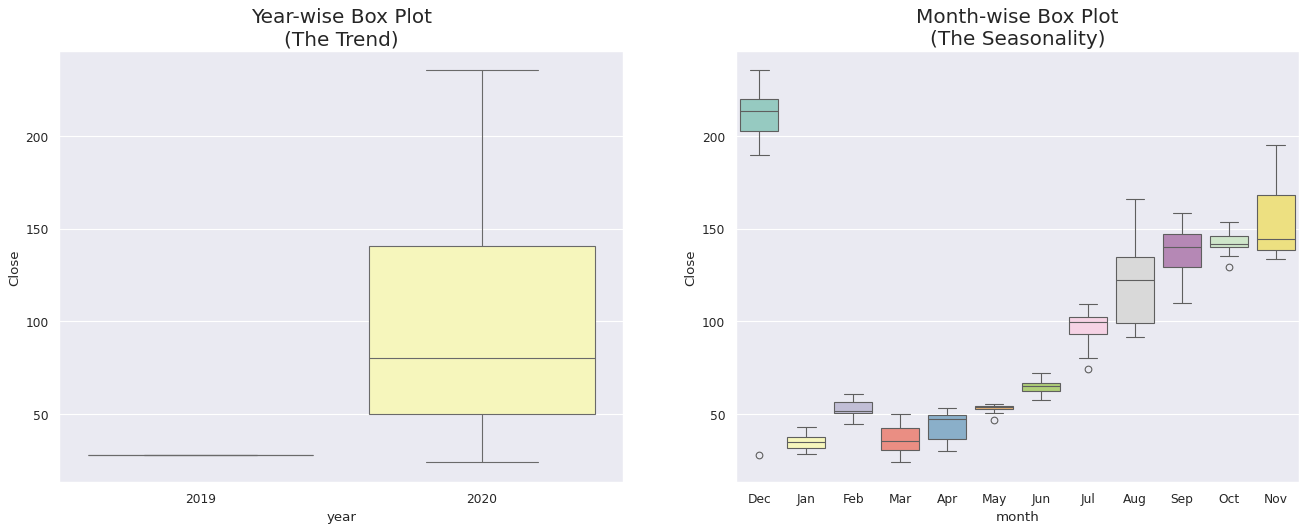

In [289]:
# Import Data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv', parse_dates=['Date'], index_col='Date')
df.reset_index(inplace=True)

# Prepare data
df['year'] = [d.year for d in df['Date']]
df['month'] = [d.strftime('%b') for d in df['Date']]
years = df['year'].unique()

# Draw Plot
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi= 80)
sns.boxplot(x='year', y='Close', data=df, ax=axes[0], palette='Set3')
sns.boxplot(x='month', y='Close', data=df, ax=axes[1], palette='Set3')

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18); 
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)
plt.show()

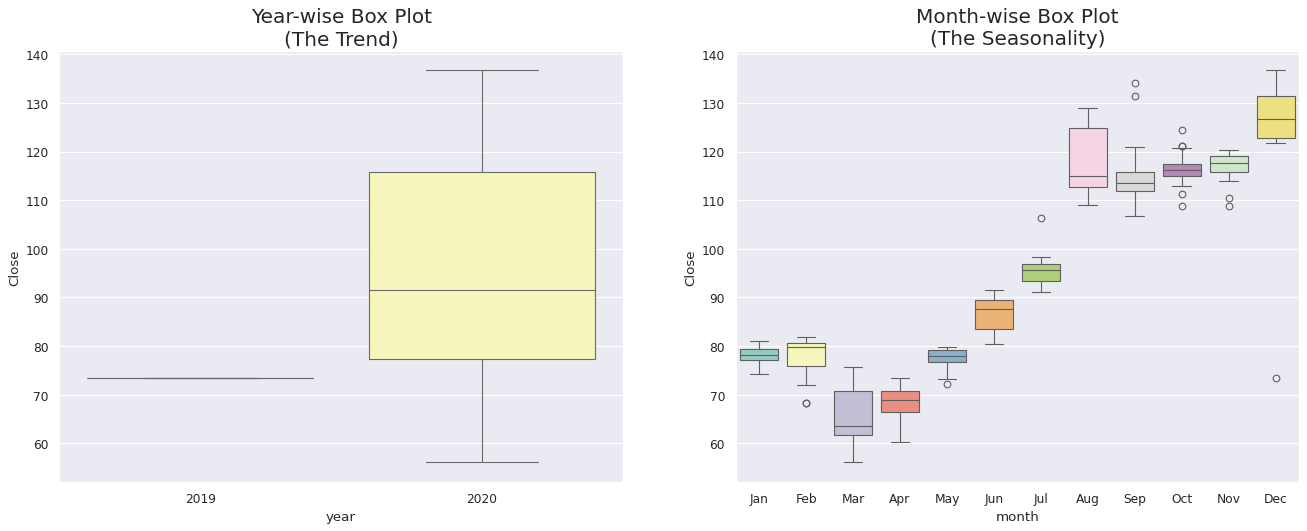

In [290]:
# Import Data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')
df.reset_index(inplace=True)

# Prepare data
df['year'] = [d.year for d in df['Date']]
df['month'] = [d.strftime('%b') for d in df['Date']]
years = df['year'].unique()

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# Draw Plot
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi= 80)
sns.boxplot(x='year', y='Close', data=df, ax=axes[0], palette='Set3')
sns.boxplot(x='month', y='Close', data=df, ax=axes[1], palette='Set3')

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18); 
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)
plt.show()

Patterns in a time series

<Axes: title={'center': 'Trend and Seasonality'}, xlabel='Date'>

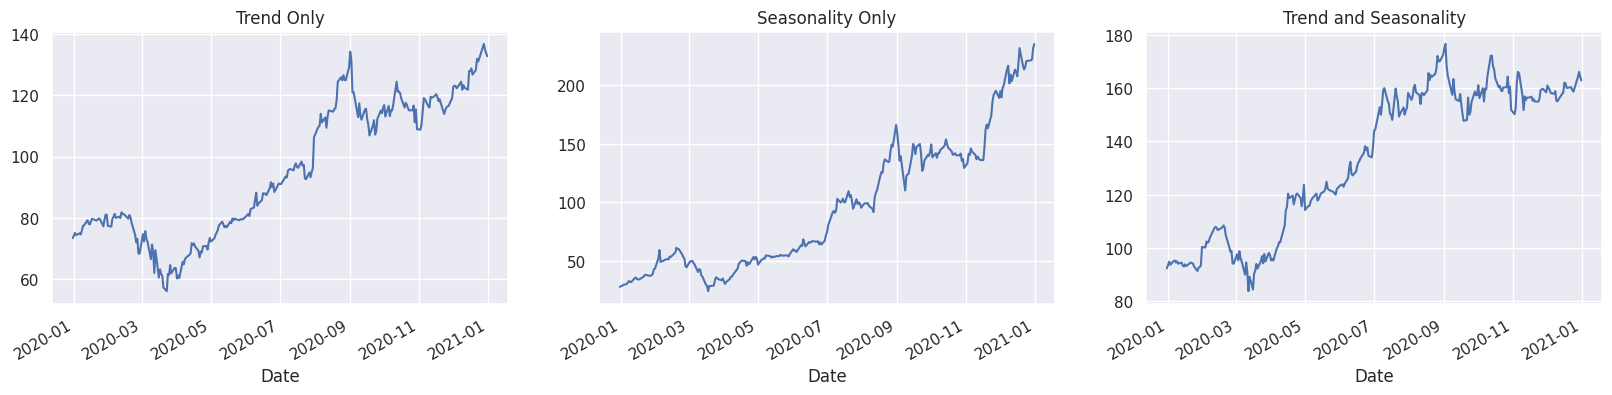

In [291]:
fig, axes = plt.subplots(1,3, figsize=(20,4), dpi=100)
pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')['Close'].plot(title='Trend Only', legend=False, ax=axes[0])

pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv', parse_dates=['Date'], index_col='Date')['Close'].plot(title='Seasonality Only', legend=False, ax=axes[1])

pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/amzn_features.csv', parse_dates=['Date'], index_col='Date')['Close'].plot(title='Trend and Seasonality', legend=False, ax=axes[2])

How to decompose a time series into its components?

In [292]:
import sys
!{sys.executable} -m pip install statsmodels

3291.25s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


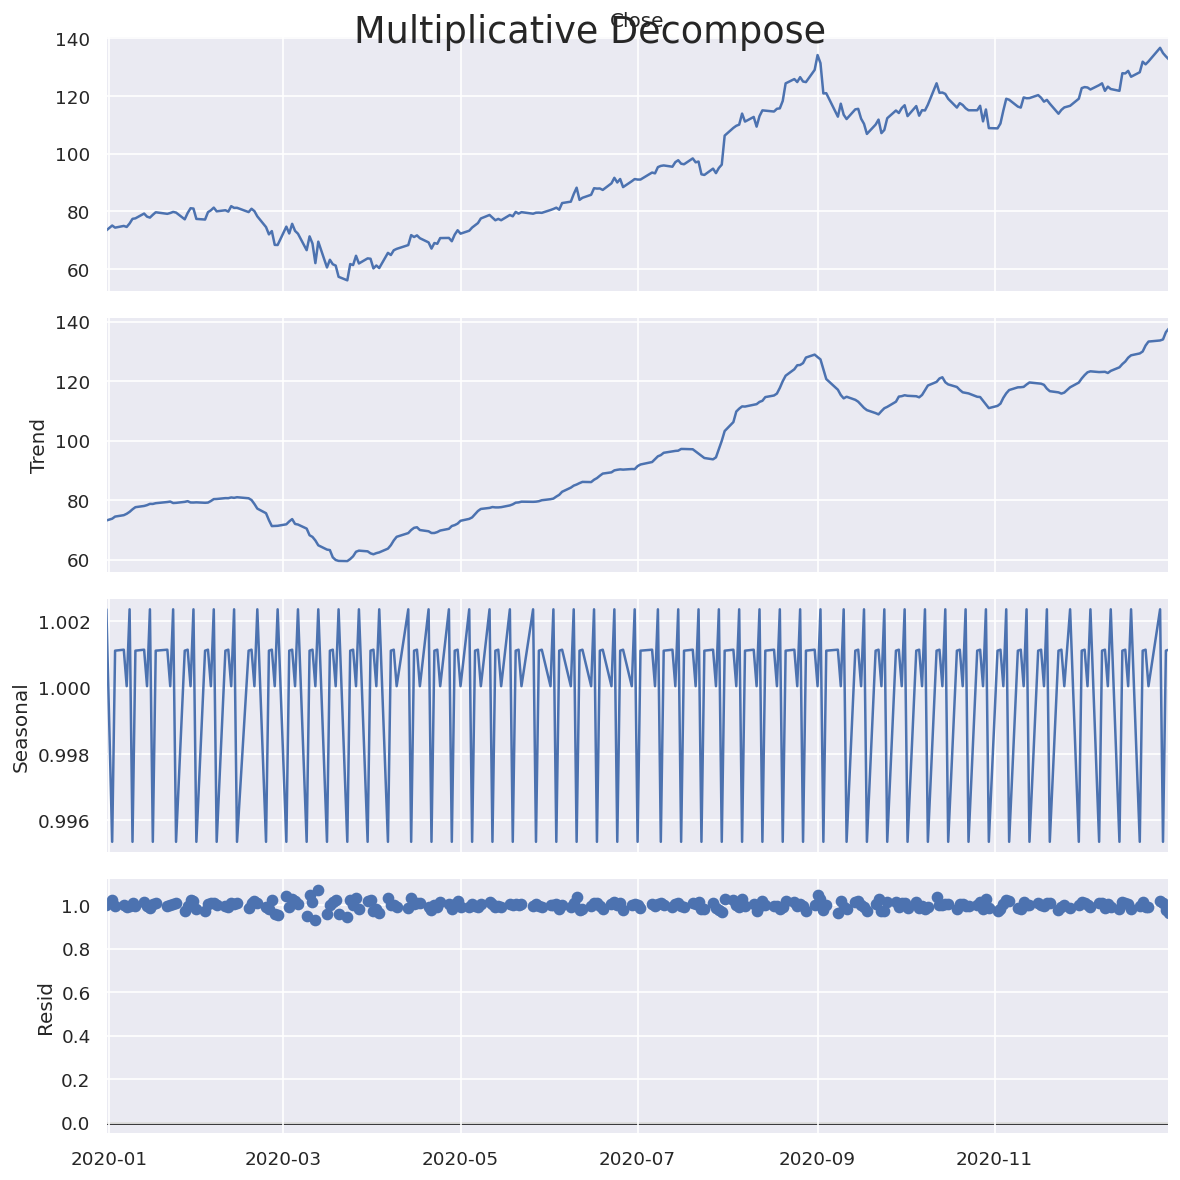

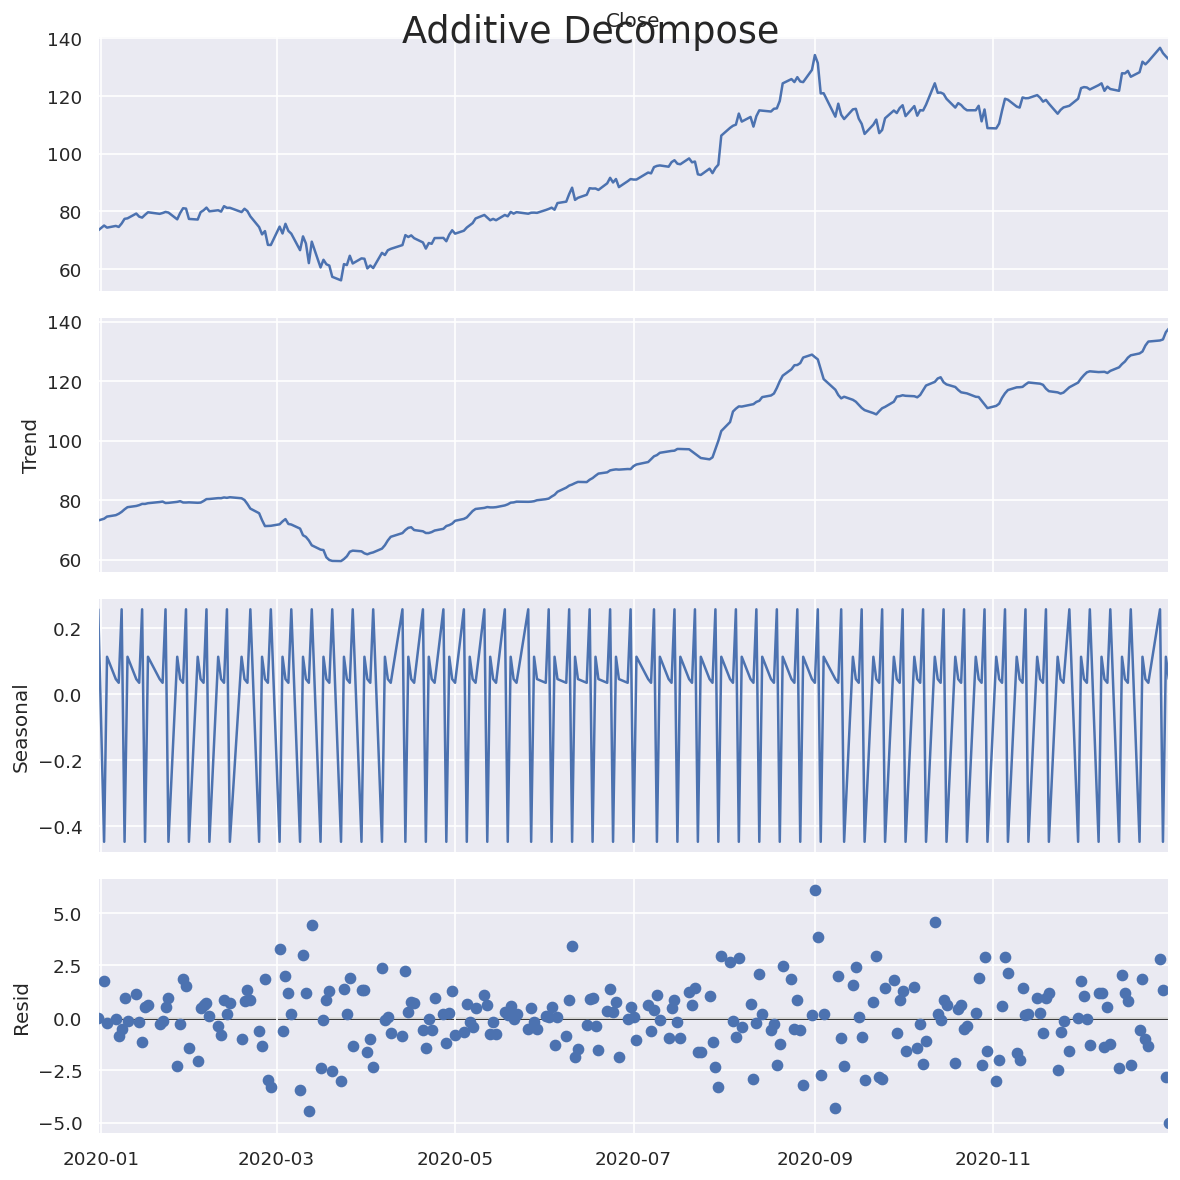

In [293]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse
%matplotlib inline

# Import Data
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'], index_col='Date')

# Multiplicative Decomposition 
result_mul = seasonal_decompose(df['Close'], model='multiplicative', period=5, extrapolate_trend='freq')

# Additive Decomposition
result_add = seasonal_decompose(df['Close'], model='additive', period=5, extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (10,10)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=22)
result_add.plot().suptitle('Additive Decompose', fontsize=22)
plt.show()

In [294]:
# Extract the Components ----
# Actual Values = Product of (Seasonal * Trend * Resid)
df_reconstructed = pd.concat([result_mul.seasonal, result_mul.trend, result_mul.resid, result_mul.observed], axis=1)
df_reconstructed.columns = ['seas', 'trend', 'resid', 'actual_values']
df_reconstructed.head()

,seas,trend,resid,actual_values
Date,,,,
2019-12-31,1.002364,73.1718,1.000923,73.412498
2020-01-02,0.995337,73.7715,1.022607,75.087502
2020-01-03,1.001114,74.4810,0.997231,74.357498
2020-01-06,1.001144,74.9580,0.998751,74.949997
2020-01-07,1.000041,75.4220,0.989028,74.597504


In [295]:
from statsmodels.tsa.stattools import adfuller, kpss
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'])

# ADF Test
result = adfuller(df['Close'].values, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

# KPSS Test
result = kpss(df['Close'].values, regression='c')
print('\nKPSS Statistic: %f' % result[0])
print('p-value: %f' % result[1])
for key, value in result[3].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -0.12702885454878415
p-value: 0.9466789170863883
Critial Values:
   1%, -3.4565688966099373
Critial Values:
   5%, -2.8730786194395455
Critial Values:
   10%, -2.5729189953388762

KPSS Statistic: 2.143463
p-value: 0.010000
Critial Values:
   10%, 0.347
Critial Values:
   5%, 0.463
Critial Values:
   2.5%, 0.574
Critial Values:
   1%, 0.739


Noise and a stationary series

<Axes: title={'center': 'AAPL Returns'}>

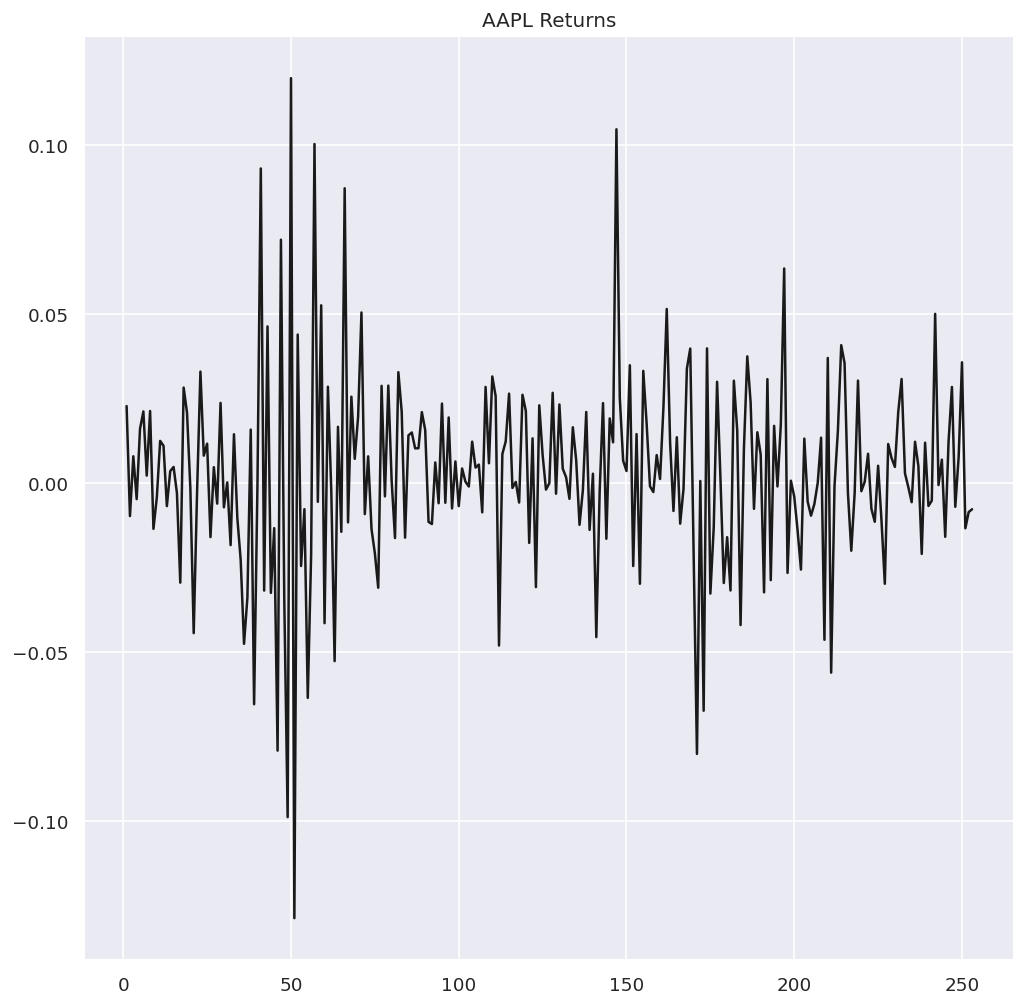

In [296]:
df['Returns'] = df['Close'].pct_change()

df['Returns'].plot(
    title='AAPL Returns',
    color='k'
)

How to detrend a time series?

Text(0.5, 1.0, 'MSFT Close Price detrended by subtracting the least squares fit')

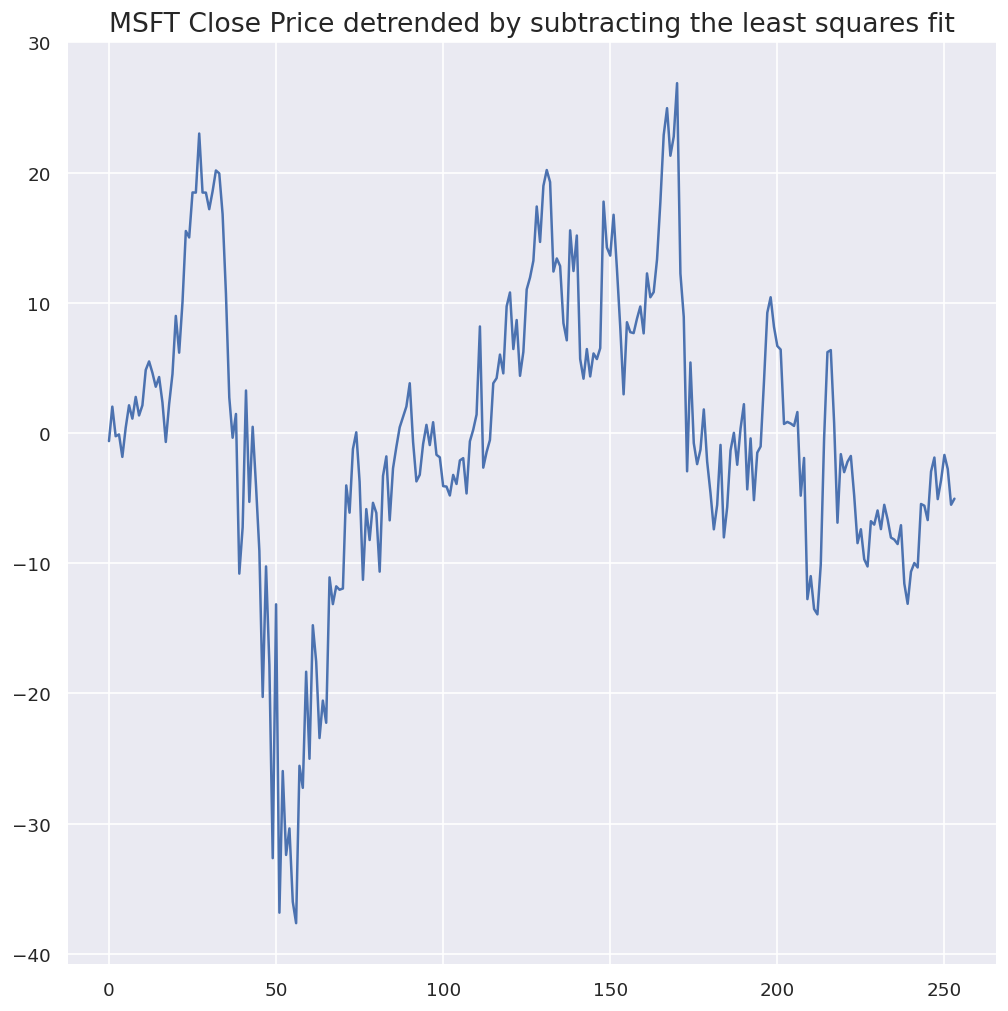

In [297]:
# Using scipy: Subtract the line of best fit
from scipy import signal
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv', parse_dates=['Date'])
detrended = signal.detrend(df['Close'].values)
plt.plot(detrended)
plt.title('MSFT Close Price detrended by subtracting the least squares fit', fontsize=16)

Text(0.5, 1.0, 'MSFT Close Price Detrended by Subtracting the Trend Component')

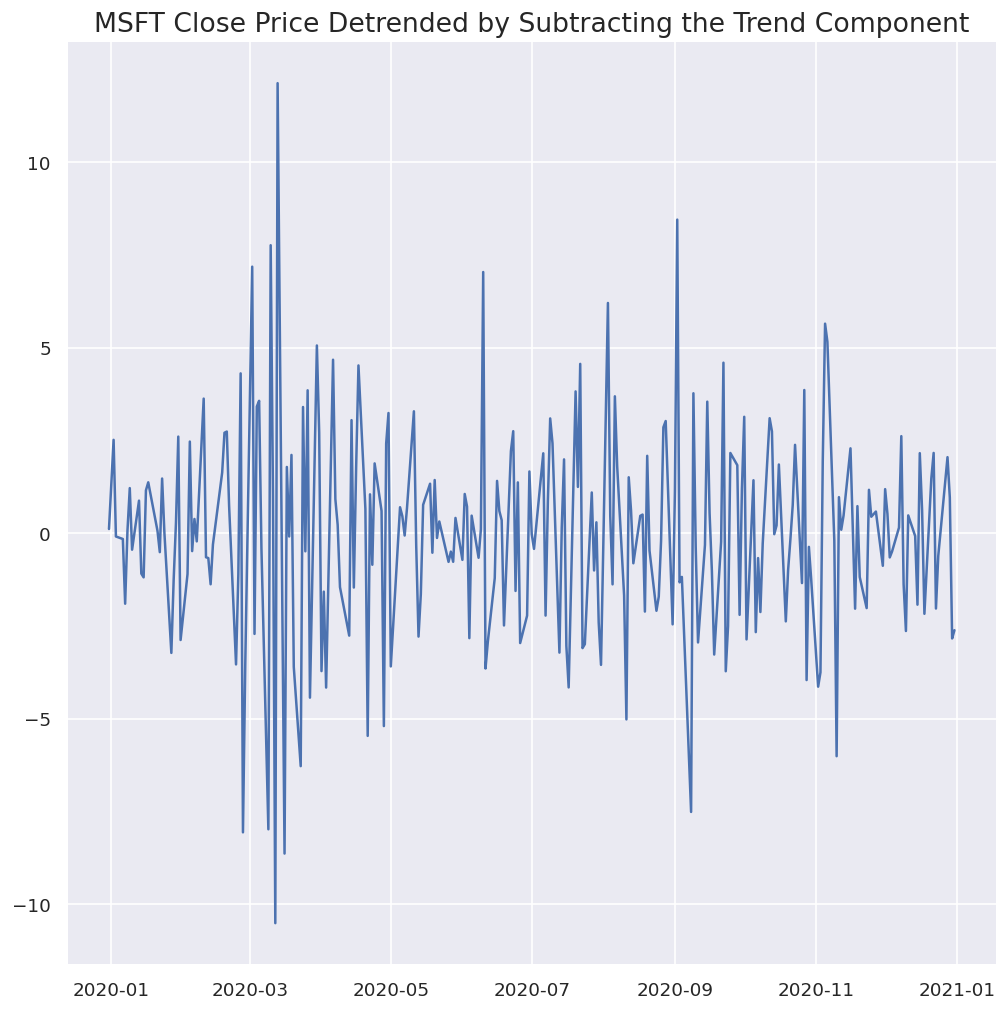

In [298]:
# Using statmodels: Subtracting the Trend Component.
from statsmodels.tsa.seasonal import seasonal_decompose
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv', parse_dates=['Date'], index_col='Date')
result_mul = seasonal_decompose(df['Close'], model='multiplicative', period=5, extrapolate_trend='freq')
detrended = df['Close'].values - result_mul.trend
plt.plot(detrended)
plt.title('MSFT Close Price Detrended by Subtracting the Trend Component', fontsize=16)

How to deseasonalize a time series?

[]

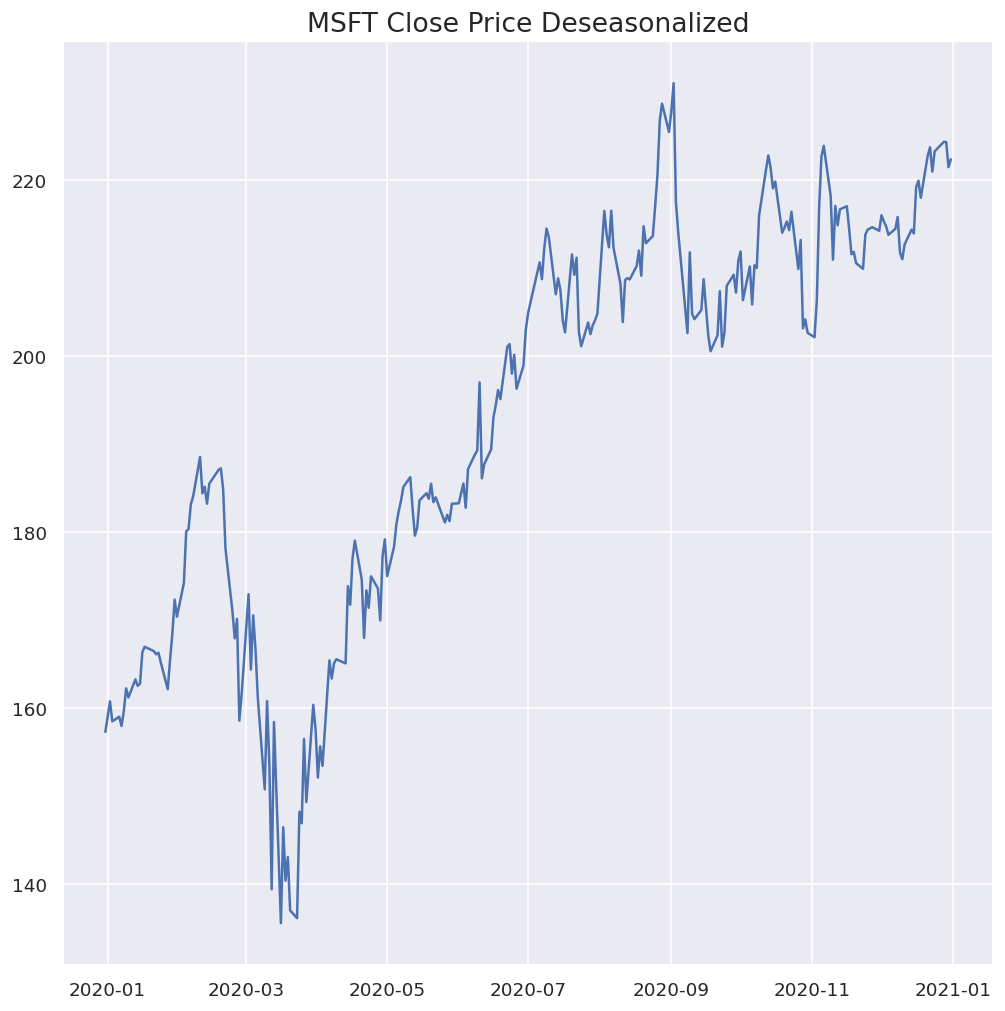

In [299]:
# Subtracting the Trend Component.
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv', parse_dates=['Date'], index_col='Date')

# Time Series Decomposition
result_mul = seasonal_decompose(df['Close'], model='multiplicative', period=5, extrapolate_trend='freq')

# Deseasonalize
deseasonalized = df['Close'].values / result_mul.seasonal

# Plot
plt.plot(deseasonalized)
plt.title('MSFT Close Price Deseasonalized', fontsize=16)
plt.plot()

How to test for seasonality of a time series?

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

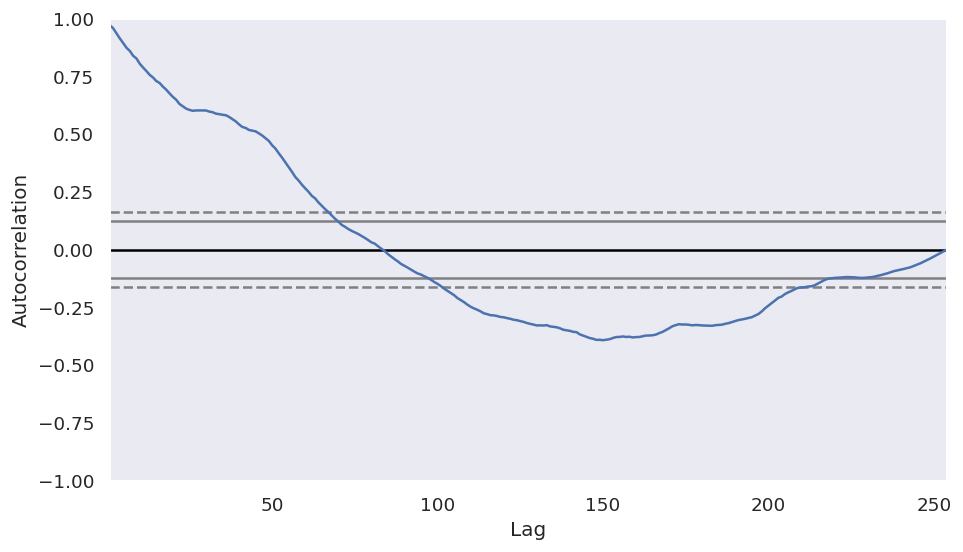

In [300]:
from pandas.plotting import autocorrelation_plot
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')

# Draw Plot
plt.rcParams.update({'figure.figsize':(9,5), 'figure.dpi':120})
autocorrelation_plot(df['Close'].tolist())

What is autocorrelation and partial autocorrelation functions?

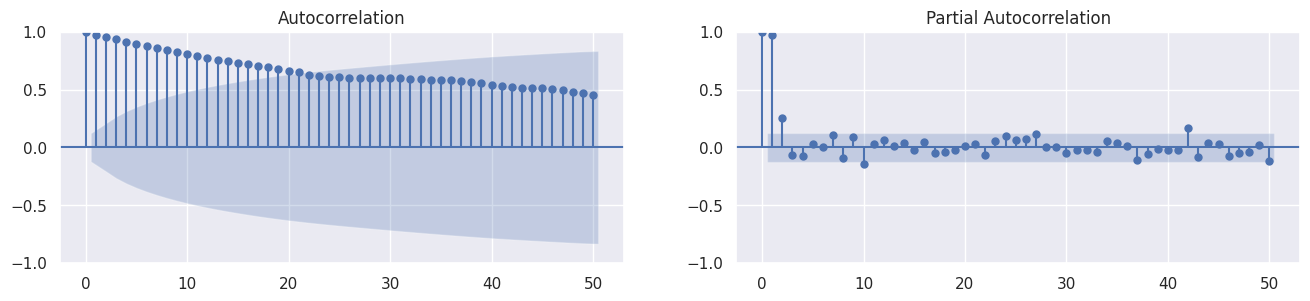

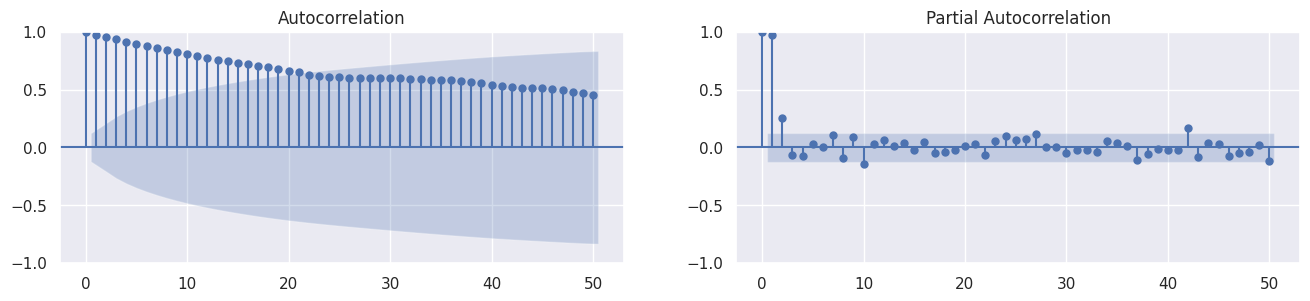

In [301]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')

# Calculate ACF and PACF upto 50 lags
# acf_50 = acf(df['Close'], nlags=50)
# pacf_50 = pacf(df['Close'], nlags=50)

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(df['Close'].tolist(), lags=50, ax=axes[0])
plot_pacf(df['Close'].tolist(), lags=50, ax=axes[1])

Lag Plots

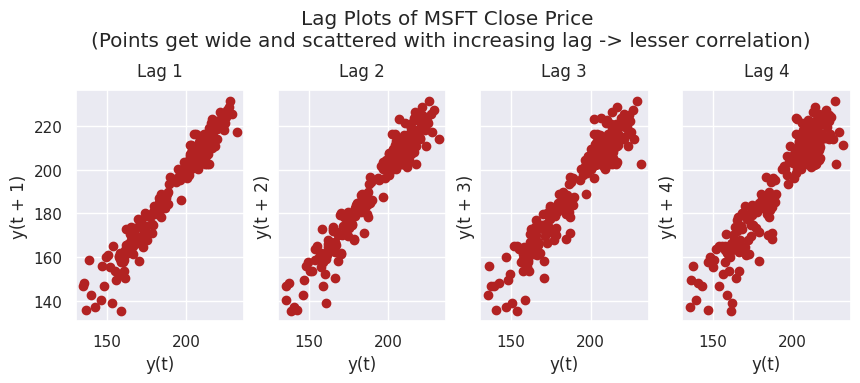

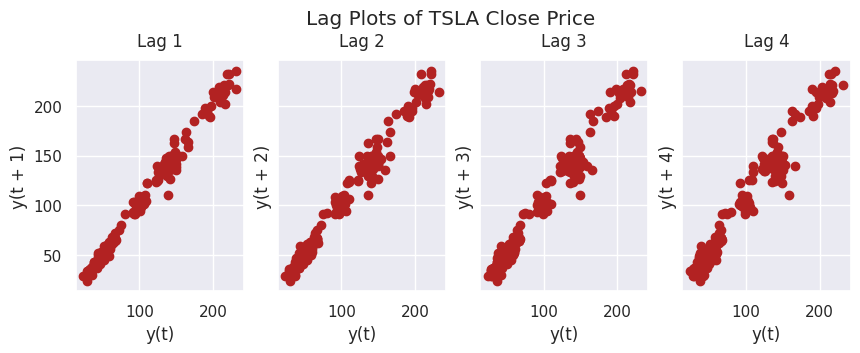

In [302]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Import
ss = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')
a10 = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv')

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(ss['Close'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of MSFT Close Price \n(Points get wide and scattered with increasing lag -> lesser correlation)\n', y=1.15)    

fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(a10['Close'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of TSLA Close Price', y=1.05)    
plt.show()


How to estimate the forecastability of a time series?

In [303]:
# https://en.wikipedia.org/wiki/Approximate_entropy
ss = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')
a10 = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv') # drug sells
rand_small = np.random.randint(0, 100, size=36)
rand_big = np.random.randint(0, 100, size=136)

def ApEn(U, m, r):
    """Compute Aproximate entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    N = len(U)
    return abs(_phi(m+1) - _phi(m))

print(ApEn(ss['Close'], m=2, r=0.2*np.std(ss['Close'])))     # 0.651
print(ApEn(a10['Close'], m=2, r=0.2*np.std(a10['Close'])))   # 0.537
print(ApEn(rand_small, m=2, r=0.2*np.std(rand_small))) # 0.143
print(ApEn(rand_big, m=2, r=0.2*np.std(rand_big)))     # 0.716

0.5710304061990947
0.21796380994290088
0.16083502693096996
0.5972926771842966


In [304]:
# https://en.wikipedia.org/wiki/Sample_entropy
def SampEn(U, m, r):
    """Compute Sample entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        return sum(C)

    N = len(U)
    return -np.log(_phi(m+1) / _phi(m))

print(SampEn(ss['Close'], m=2, r=0.2*np.std(ss['Close'])))      # 0.78
print(SampEn(a10['Close'], m=2, r=0.2*np.std(a10['Close'])))    # 0.41
print(SampEn(rand_small, m=2, r=0.2*np.std(rand_small)))  # 1.79
print(SampEn(rand_big, m=2, r=0.2*np.std(rand_big)))      # 2.42

0.47085308294367295
0.14156356432178688
inf
2.0794415416798357


How to use Granger Causality test to know if one time series is helpful in forecasting another?

In [305]:
from statsmodels.tsa.stattools import grangercausalitytests
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv', parse_dates=['Date'])

# Remove missing values
df = df[['Close', 'avg_sentiment']].dropna()

grangercausalitytests(df[['Close', 'avg_sentiment']], maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1741  , p=0.6768  , df_denom=250, df_num=1
ssr based chi2 test:   chi2=0.1762  , p=0.6746  , df=1
likelihood ratio test: chi2=0.1762  , p=0.6747  , df=1
parameter F test:         F=0.1741  , p=0.6768  , df_denom=250, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.6402  , p=0.5281  , df_denom=247, df_num=2
ssr based chi2 test:   chi2=1.3062  , p=0.5204  , df=2
likelihood ratio test: chi2=1.3029  , p=0.5213  , df=2
parameter F test:         F=0.6402  , p=0.5281  , df_denom=247, df_num=2


{np.int64(1): ({'ssr_ftest': (np.float64(0.17414346239183137),
    np.float64(0.6768134685795656),
    np.float64(250.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.17623318394053333),
    np.float64(0.6746305694912718),
    np.int64(1)),
   'lrtest': (np.float64(0.17617183271568138),
    np.float64(0.6746839601616024),
    np.int64(1)),
   'params_ftest': (np.float64(0.17414346239159437),
    np.float64(0.6768134685797728),
    np.float64(250.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.6401622014996868),
    np.float64(0.5280793235955015),
    np.float64(247.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(1.3062419010357982),
    np.float64(0.5204190375304039),
    np.int64(2)),
   'lrtest': (np.float64(1.3028681025452897),
    np.float64(0.5212976728883347),
    np.int64(2)),
   'params_ftest': (np.float64(0.6401622014996571),
    np.float64(0.5280793235955171),
    np.float64(247.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
  

# ARIMA and Seasonal ARIMA
## Autoregressive Integrated Moving Averages
The general process for ARIMA models is the following:

- Visualize the Time Series Data
- Make the time series data stationary
- Plot the Correlation and AutoCorrelation Charts
- Construct the ARIMA Model or Seasonal ARIMA based on the data
- Use the model to make predictions

Let's go through these steps!

In [205]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [206]:
df=pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv')

In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
0,2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaN,NaN,0.000000,NaN
1,2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
3,2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
4,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


In [207]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
249,2020-12-24,131.320007,133.460007,131.100006,131.970001,129.679718,54930100,2020-12-24,AAPL,-0.128000,1.0
250,2020-12-28,133.990005,137.339996,133.509995,136.690002,134.317825,124486200,2020-12-28,AAPL,0.288850,2.0
251,2020-12-29,138.050003,138.789993,134.339996,134.869995,132.529404,121047300,2020-12-29,AAPL,0.000000,2.0
252,2020-12-30,135.580002,135.990005,133.399994,133.720001,131.399368,96452100,2020-12-30,AAPL,0.000000,1.0
253,2020-12-31,134.080002,134.740005,131.720001,132.690002,130.387222,99116600,2020-12-31,AAPL,0.076167,3.0


In [208]:
## Cleaning up the data
df = df[["Date", "Close", "avg_sentiment"]]

df.head()

,Date,Close,avg_sentiment
0,2019-12-31,73.412498,0.000000
1,2020-01-02,75.087502,0.376125
2,2020-01-03,74.357498,0.103833
3,2020-01-06,74.949997,0.779300
4,2020-01-07,74.597504,0.069367


In [209]:
# Convert Month into Datetime 
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df.head()

,Close,avg_sentiment
Date,,
2019-12-31,73.412498,0.000000
2020-01-02,75.087502,0.376125
2020-01-03,74.357498,0.103833
2020-01-06,74.949997,0.779300
2020-01-07,74.597504,0.069367


In [210]:
df.describe()

,Close,avg_sentiment
count,254.000000,254.000000
mean,95.260718,0.093034
std,21.810137,0.181274
min,56.092499,-0.421500
25%,77.379377,0.000000
50%,91.421249,0.070178
75%,115.739374,0.219082
max,136.690002,0.779300


Step 2: Visualize the Data

<Axes: xlabel='Date'>

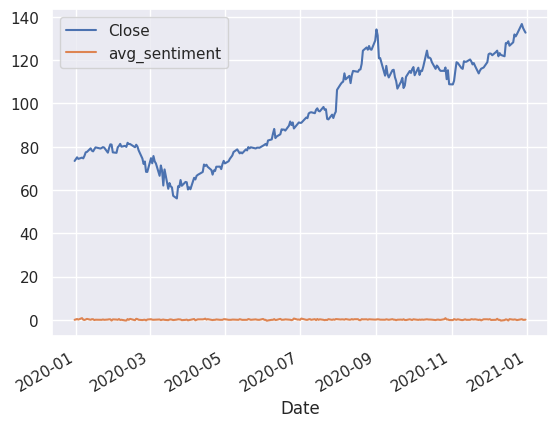

In [211]:
df.plot()

In [212]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [213]:
test_result=adfuller(df['Close'])

In [214]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(close_price):
    result=adfuller(close_price)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


In [215]:
adfuller_test(df['Close'])

ADF Test Statistic : -0.12702885454878415
p-value : 0.9466789170863883
#Lags Used : 1
Number of Observations Used : 252
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


Differencing

In [216]:
df['Close First Difference'] = df['Close'] - df['Close'].shift(1)

In [217]:
df['Close'].shift(1)

Date
2019-12-31           NaN
2020-01-02     73.412498
2020-01-03     75.087502
2020-01-06     74.357498
2020-01-07     74.949997
2020-01-08     74.597504
2020-01-09     75.797501
2020-01-10     77.407501
2020-01-13     77.582497
2020-01-14     79.239998
2020-01-15     78.169998
2020-01-16     77.834999
2020-01-17     78.809998
2020-01-21     79.682503
2020-01-22     79.142502
2020-01-23     79.425003
2020-01-24     79.807503
2020-01-27     79.577499
2020-01-28     77.237503
2020-01-29     79.422501
2020-01-30     81.084999
2020-01-31     80.967499
2020-02-03     77.377502
2020-02-04     77.165001
2020-02-05     79.712502
2020-02-06     80.362503
2020-02-07     81.302498
2020-02-10     80.007500
2020-02-11     80.387497
2020-02-12     79.902496
2020-02-13     81.800003
2020-02-14     81.217499
2020-02-18     81.237503
2020-02-19     79.750000
2020-02-20     80.904999
2020-02-21     80.074997
2020-02-24     78.262497
2020-02-25     74.544998
2020-02-26     72.019997
2020-02-27     73.16

In [218]:
df.head(14)

,Close,avg_sentiment,Close First Difference
Date,,,
2019-12-31,73.412498,0.000000,NaN
2020-01-02,75.087502,0.376125,1.675003
2020-01-03,74.357498,0.103833,-0.730003
2020-01-06,74.949997,0.779300,0.592499
2020-01-07,74.597504,0.069367,-0.352493
2020-01-08,75.797501,-0.062567,1.199997
2020-01-09,77.407501,0.153100,1.610001
2020-01-10,77.582497,0.426825,0.174995
2020-01-13,79.239998,0.026950,1.657501


In [219]:
## Again test dickey fuller test
adfuller_test(df['Close First Difference'].dropna())

ADF Test Statistic : -18.972801652135207
p-value : 0.0
#Lags Used : 0
Number of Observations Used : 252
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<Axes: xlabel='Date'>

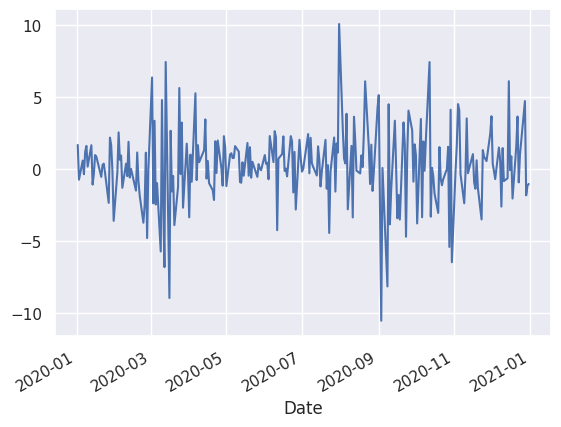

In [220]:
df['Close First Difference'].plot()


Auto Regressive Model

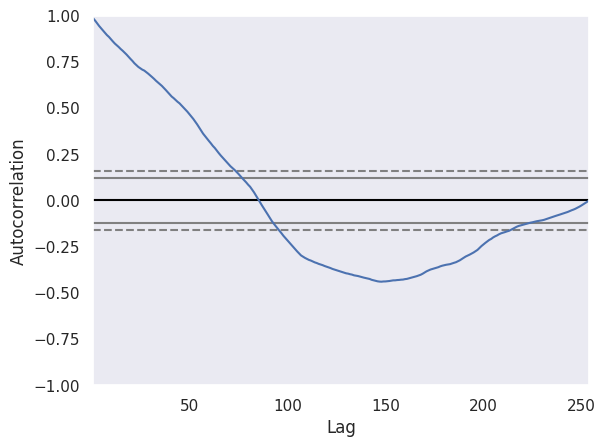

In [221]:
from pandas.plotting import autocorrelation_plot, scatter_matrix
autocorrelation_plot(df['Close'])
plt.show()

Final Thoughts on Autocorrelation and Partial Autocorrelation

In [222]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm

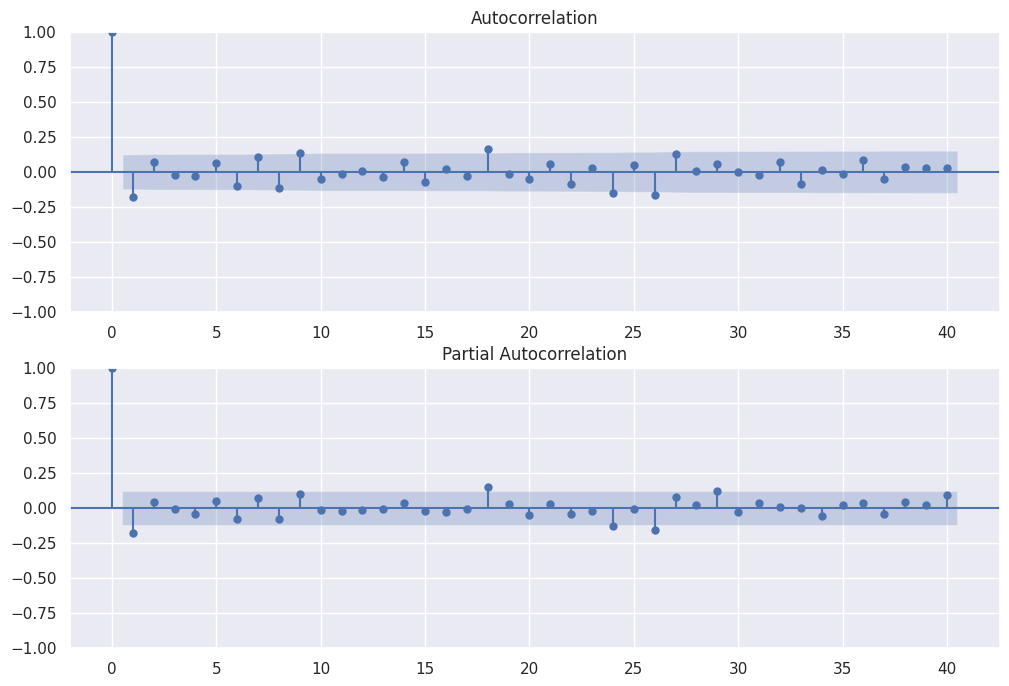

In [223]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Close First Difference'].dropna(),lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Close First Difference'].dropna(),lags=40,ax=ax2)

In [224]:
# For non-seasonal data
#p=1, d=1, q=0 or 1
from statsmodels.tsa.arima_model import ARIMA

In [225]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(df['Close'],order=(1,1,1))
model_fit=model.fit()

In [226]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  254
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -597.411
Date:                Sat, 30 May 2026   AIC                           1200.821
Time:                        23:27:00   BIC                           1211.422
Sample:                             0   HQIC                          1205.086
                                - 254                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3787      0.264     -1.437      0.151      -0.895       0.138
ma.L1          0.2135      0.281      0.761      0.447      -0.336       0.763
sigma2         6.5837      0.389     16.904      0.000       5.820       7.347
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                81.22
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               1.40   Skew:                            -0.23
Prob(H) (two-sided):                  0.12   Kurtosis:                         5.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='Date'>

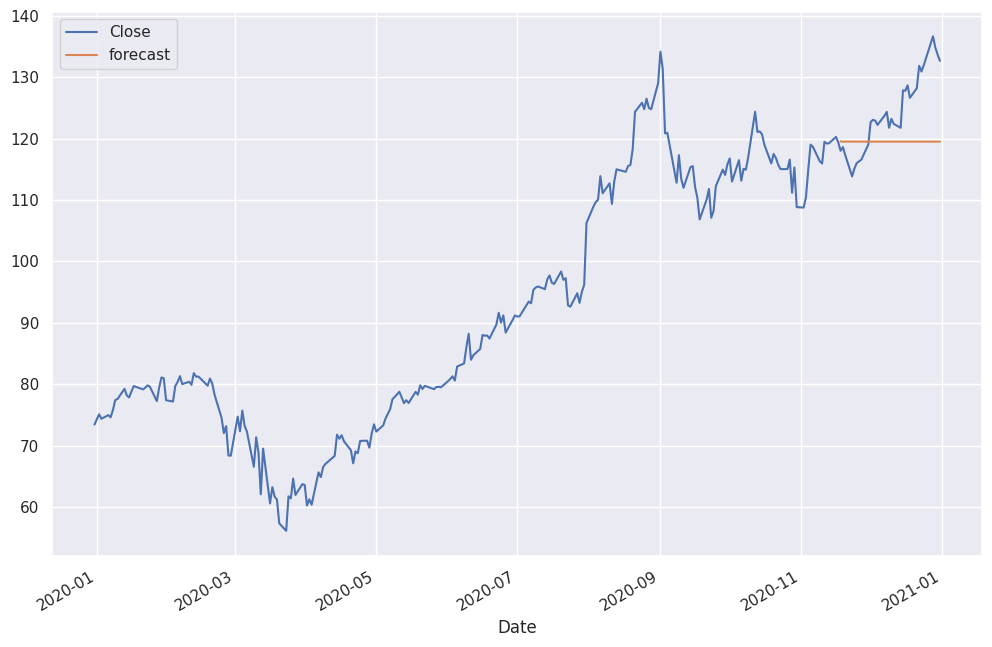

In [227]:
df['forecast']=model_fit.predict(start=len(df)-30, end=len(df)-1, dynamic=True)
df[['Close','forecast']].plot(figsize=(12,8))

In [228]:
import statsmodels.api as sm

In [229]:
model=sm.tsa.statespace.SARIMAX(df['Close'],order=(1, 1, 1),seasonal_order=(1,1,1,12))
results=model.fit()

In [230]:
df.shape

(254, 4)

<Axes: xlabel='Date'>

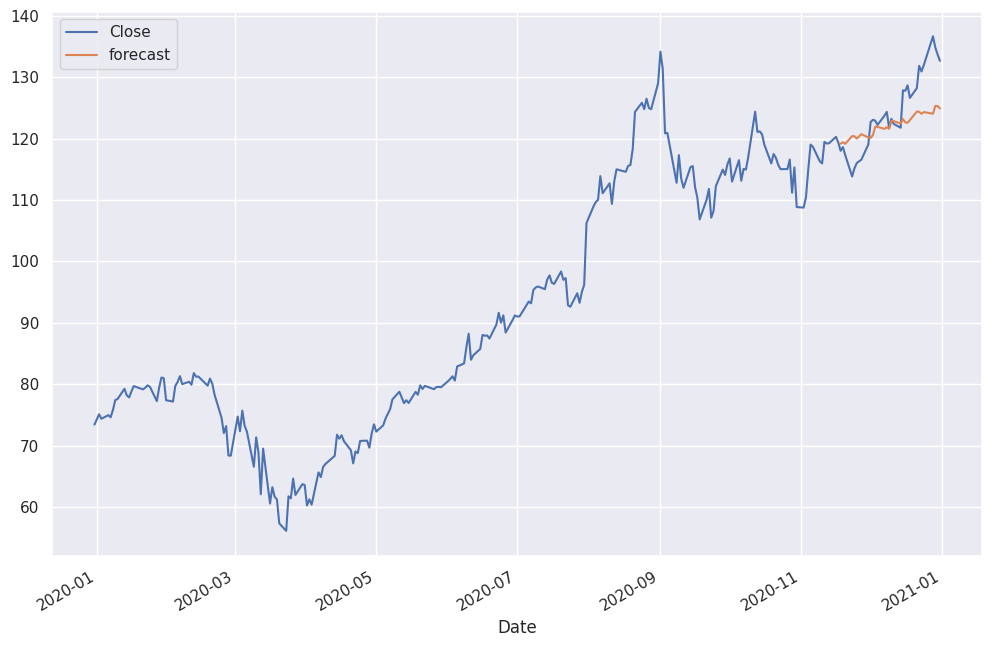

In [231]:
df['forecast']=results.predict(start=len(df)-30, end=len(df)-1,dynamic=True)
df[['Close','forecast']].plot(figsize=(12,8))

In [232]:
from pandas.tseries.offsets import BDay
future_dates=[df.index[-1]+ BDay(x) for x in [1,3,5]]

In [233]:
future_dates

[Timestamp('2021-01-01 00:00:00'),
 Timestamp('2021-01-05 00:00:00'),
 Timestamp('2021-01-07 00:00:00')]

In [234]:
future_datest_df=pd.DataFrame(index=future_dates[1:],columns=df.columns)

In [235]:
future_datest_df.tail()

,Close,avg_sentiment,Close First Difference,forecast
2021-01-05,NaN,NaN,NaN,NaN
2021-01-07,NaN,NaN,NaN,NaN


In [236]:
future_df=pd.concat([df,future_datest_df])

<Axes: xlabel='Date'>

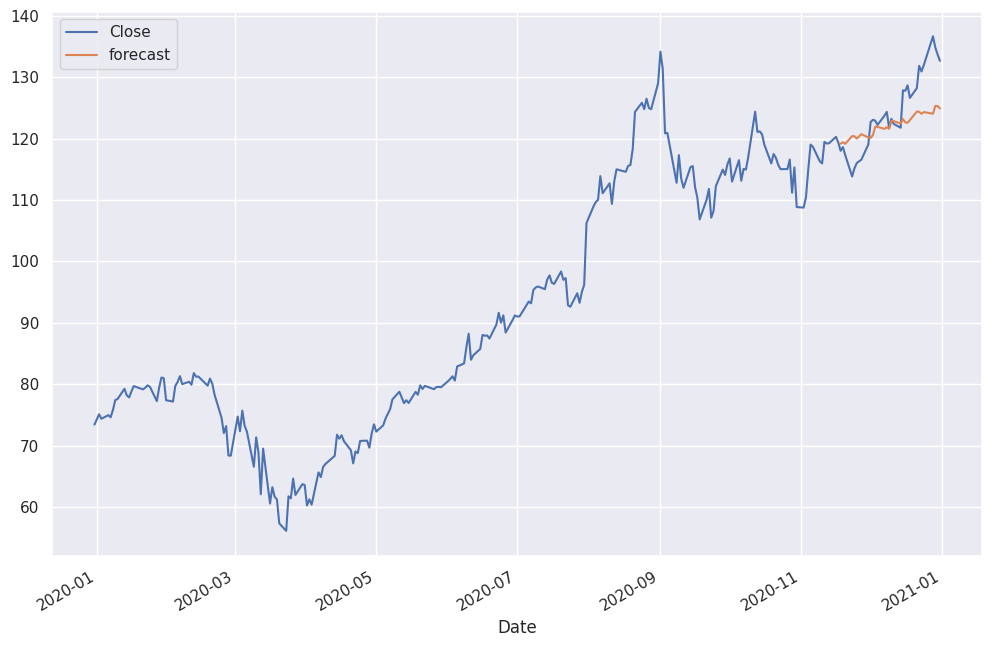

In [237]:
future_df = df.copy()
future_df['forecast'] = results.predict(start=len(df)-30, end=len(df)-1, dynamic= True)
future_df[['Close', 'forecast']].plot(figsize=(12, 8))

# 5 Loop through companies

In [238]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

In [239]:
# Company files
company_files = {
    "AAPL": "/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv",
    "MSFT": "/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv",
    "GOOG": "/home/chakuunaa/BD_ADA_CA2sem2/data/goog_features.csv",
    "TSLA": "/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv",
    "AMZN": "/home/chakuunaa/BD_ADA_CA2sem2/data/amzn_features.csv"
}

# Empty list
results_list = []

In [240]:
# Loop through companies
for company, path in company_files.items():

    # Read data
    df = pd.read_csv(path, parse_dates=['Date'])

    # Keep Close column only
    series = df['Close'].dropna()

    # Build ARIMA model
    model = ARIMA(series, order=(1,1,1))

    results = model.fit()

    # Forecast next 5 days
    forecast_values = results.forecast(steps=5)

    # Save results
    results_list.append({
        "Company": company,
        "1 Day Forecast": forecast_values.iloc[0],
        "3 Day Forecast": forecast_values.iloc[2],
        "5 Day Forecast": forecast_values.iloc[4]
    })

# Final table
forecast_table = pd.DataFrame(results_list)

forecast_table

,Company,1 Day Forecast,3 Day Forecast,5 Day Forecast
0,AAPL,132.840450,132.805051,132.799973
1,MSFT,222.120321,222.192292,222.203854
2,GOOG,87.422214,87.463118,87.469369
3,TSLA,235.178537,235.186210,235.186579
4,AMZN,162.923288,162.905905,162.898476


In [241]:
forecast_table.to_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/all_company_forecasts.csv",
    index=False
)

# Forecasting_model_comparison

In [ ]:
#pip install statsmodels

In [ ]:
#pip install yfinance

In [ ]:
import pandas as pd 
import datetime
import yfinance as yfin

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_model import ARIMA

#relax the display limits on columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings('ignore')


In [ ]:
msft = yfin.download(['MSFT'], start="2018-01-01", end="2020-12-02")

msft.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
2018-01-02,78.699890,79.029524,78.287852,78.864707,22483800
2018-01-03,79.066132,79.212638,78.718188,78.800593,26061400
2018-01-04,79.762077,80.265686,79.267627,79.285937,21912000
2018-01-05,80.750961,80.952405,80.055067,80.265669,23407100
2018-01-08,80.833359,81.108056,80.210718,80.760105,22113000


In [ ]:
msft = msft['Close']
msft.to_csv("msft.csv")
msft = pd.read_csv("msft.csv")
msft.columns = ['Date', 'Close']
msft.head()

,Date,Close
0,2018-01-02,78.699890
1,2018-01-03,79.066132
2,2018-01-04,79.762077
3,2018-01-05,80.750961
4,2018-01-08,80.833359


In [ ]:
msft.index = pd.to_datetime(msft['Date'], format='%Y-%m-%d')
del msft['Date']

msft.head(5)

,Close
Date,
2018-01-02,78.699890
2018-01-03,79.066132
2018-01-04,79.762077
2018-01-05,80.750961
2018-01-08,80.833359


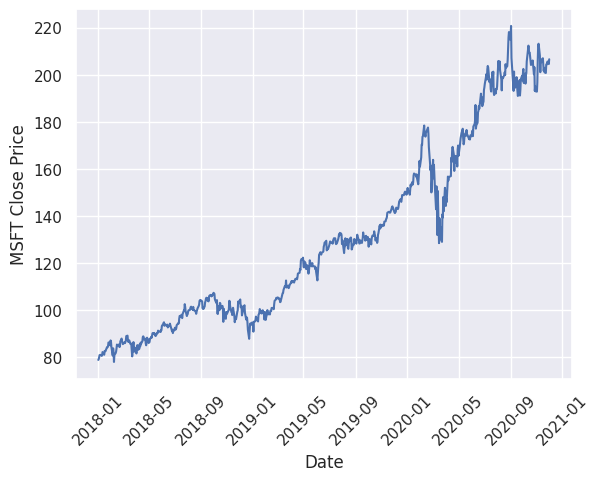

In [ ]:
sns.set()
plt.ylabel('MSFT Close Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.plot(msft.index, msft['Close'], )
plt.show()

In [ ]:
train = msft[msft.index < pd.to_datetime("2020-10-01", format='%Y-%m-%d')]
test = msft[msft.index >= pd.to_datetime("2020-10-01", format='%Y-%m-%d')]
test

,Close
Date,
2020-10-01,202.430008
2020-10-02,196.456009
2020-10-05,200.448181
2020-10-06,196.189224
2020-10-07,199.924164
2020-10-08,200.638748
2020-10-09,205.621826
2020-10-12,210.947952
2020-10-13,212.339050


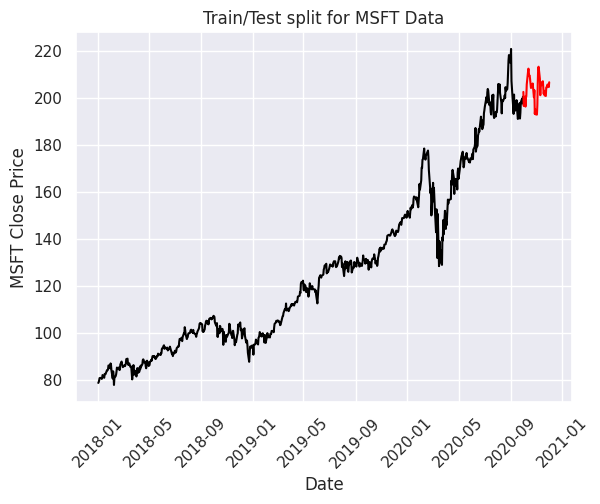

In [ ]:
plt.plot(train, color = "black", label = 'Training')
plt.plot(test, color = "red", label = 'Testing')
plt.ylabel('MSFT Close Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for MSFT Data")
plt.show()

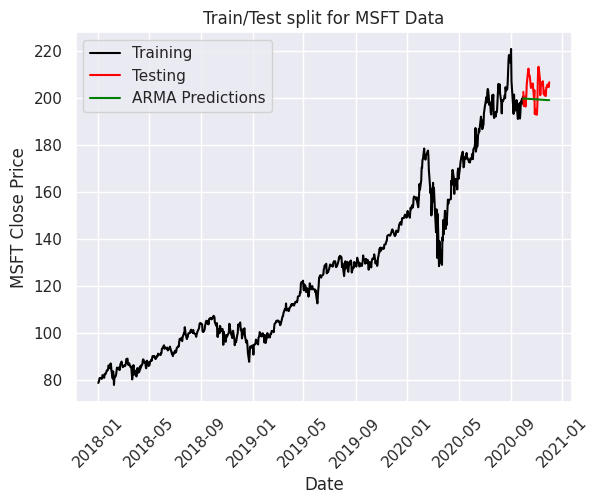

In [ ]:
y = train['Close']

ARMAmodel = SARIMAX(y, order = (1, 0, 1))
ARMAmodel = ARMAmodel.fit()

y_pred = ARMAmodel.get_forecast(len(test.index))
y_pred_df_arma = y_pred.conf_int(alpha = 0.05) 
y_pred_df_arma["Predictions"] = ARMAmodel.predict(start = y_pred_df_arma.index[0], 
                                                   end = y_pred_df_arma.index[-1])
y_pred_df_arma.index = test.index
y_pred_outARMA = y_pred_df_arma["Predictions"] 

plt.plot(train, color = "black", label = 'Training')
plt.plot(test, color = "red", label = 'Testing')
plt.ylabel('MSFT Close Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for MSFT Data")
plt.plot(y_pred_outARMA, color='green', label = 'ARMA Predictions')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

arma_rmse = np.sqrt(mean_squared_error(test["Close"].values, y_pred_df_arma["Predictions"]))
print("ARMA RMSE: ",arma_rmse)

ARMA RMSE:  6.721529185190514


In [ ]:
#ARIMAmodel = SARIMAX(y, order = (2, 2, 2))
#ARIMAmodel = SARIMAX(y, order = (2, 3, 2))
ARIMAmodel = SARIMAX(y, order = (5, 4, 2))
ARIMAmodel = ARIMAmodel.fit()

y_pred = ARIMAmodel.get_forecast(len(test.index))
y_pred_df_arima = y_pred.conf_int(alpha = 0.05) 
y_pred_df_arima["Predictions"] = ARIMAmodel.predict(start = y_pred_df_arima.index[0],
                                                     end = y_pred_df_arima.index[-1])
y_pred_df_arima.index = test.index
y_pred_outARIMA = y_pred_df_arima["Predictions"]

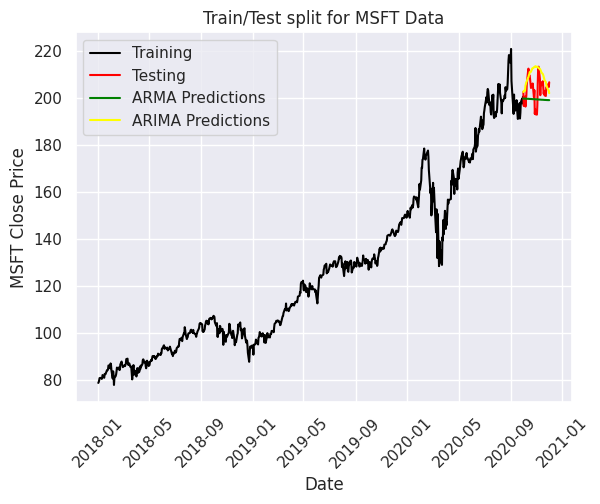

In [ ]:
plt.plot(train, color = "black", label = 'Training')
plt.plot(test, color = "red", label = 'Testing')
plt.ylabel('MSFT Close Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for MSFT Data")
plt.plot(y_pred_outARMA, color='green', label = 'ARMA Predictions')
plt.plot(y_pred_outARIMA, color='Yellow', label = 'ARIMA Predictions')
plt.legend()
plt.show()

In [ ]:
arima_rmse = np.sqrt(mean_squared_error(test["Close"].values, y_pred_df_arima["Predictions"]))
print("ARIMA RMSE: ",arima_rmse)

ARIMA RMSE:  8.410354312833464


In [ ]:
SARIMAXmodel = SARIMAX(y, order = (2,2,2), seasonal_order=(2,2,2,12))
SARIMAXmodel = SARIMAXmodel.fit()

y_pred = SARIMAXmodel.get_forecast(len(test.index))
y_pred_df_sarima = y_pred.conf_int(alpha = 0.05) 
y_pred_df_sarima["Predictions"] = SARIMAXmodel.predict(start = y_pred_df_sarima.index[0],
                                                        end = y_pred_df_sarima.index[-1])
y_pred_df_sarima.index = test.index
y_pred_outSARIMAX = y_pred_df_sarima["Predictions"] 

KeyboardInterrupt: 

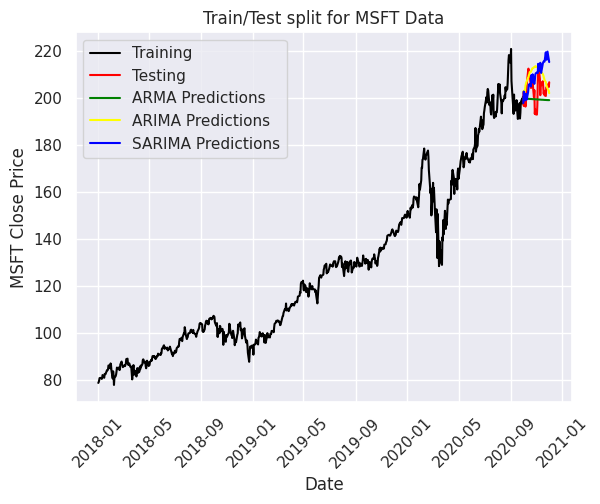

In [ ]:
plt.plot(train, color = "black", label = 'Training')
plt.plot(test, color = "red", label = 'Testing')
plt.ylabel('MSFT Close Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for MSFT Data")
plt.plot(y_pred_outARMA, color='green', label = 'ARMA Predictions')
plt.plot(y_pred_outARIMA, color='Yellow', label = 'ARIMA Predictions')
plt.plot(y_pred_outSARIMAX, color='Blue', label = 'SARIMA Predictions')
plt.legend()
plt.show()

In [ ]:
sarima_rmse = np.sqrt(mean_squared_error(test["Close"].values, y_pred_df_sarima["Predictions"]))
print("SARIMA RMSE: ",sarima_rmse)

SARIMA RMSE:  9.284470266853125


LSTM_AAPL

In [ ]:
aapl = yfin.download(['AAPL'], start="2018-01-01", end="2020-12-02")

aapl.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260063,40.802382,40.196951,40.330191,118071600
2018-01-04,40.447067,40.549921,40.224998,40.332525,89738400
2018-01-05,40.907574,40.994063,40.451747,40.542912,94640000
2018-01-08,40.755627,41.050160,40.657445,40.755627,82271200


In [ ]:
aapl = aapl['Close']
aapl.to_csv("aapl.csv")
aapl = pd.read_csv("aapl.csv")
aapl.columns = ['Date', 'Close']
aapl.head()

,Date,Close
0,2018-01-02,40.267075
1,2018-01-03,40.260063
2,2018-01-04,40.447067
3,2018-01-05,40.907574
4,2018-01-08,40.755627


In [ ]:
aapl.index = pd.to_datetime(aapl['Date'], format='%Y-%m-%d')
del aapl['Date']

aapl.head(5)

,Close
Date,
2018-01-02,40.267075
2018-01-03,40.260063
2018-01-04,40.447067
2018-01-05,40.907574
2018-01-08,40.755627


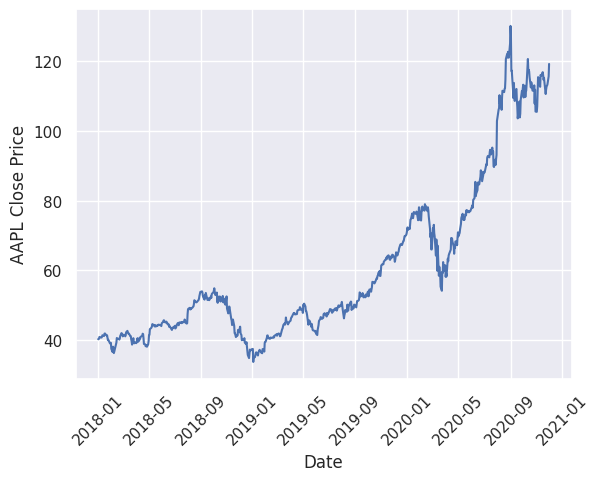

In [ ]:
sns.set()
plt.ylabel('AAPL Close Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.plot(aapl.index, aapl['Close'], )
plt.show()

In [ ]:
train = aapl[aapl.index < pd.to_datetime("2020-10-01", format='%Y-%m-%d')]
test = aapl[aapl.index >= pd.to_datetime("2020-10-01", format='%Y-%m-%d')]
test

,Close
Date,
2020-10-01,113.283226
2020-10-02,109.626404
2020-10-05,113.001930
2020-10-06,109.762207
2020-10-07,111.624573
2020-10-08,111.517860
2020-10-09,113.457809
2020-10-12,120.664726
2020-10-13,117.463814


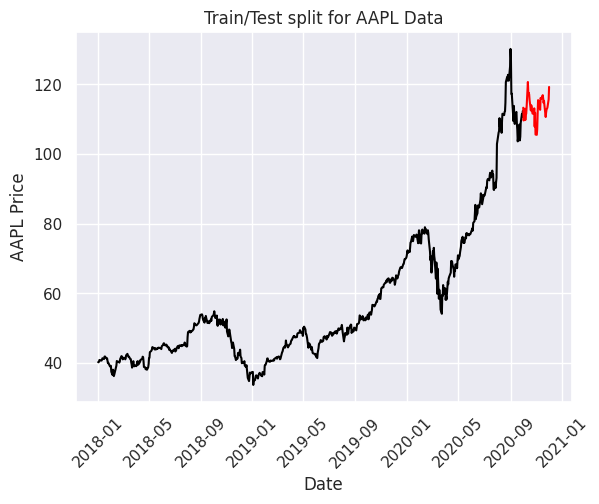

In [ ]:
plt.plot(train, color = "black", label = 'Training')
plt.plot(test, color = "red", label = 'Testing')
plt.ylabel('AAPL Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for AAPL Data")
plt.show()

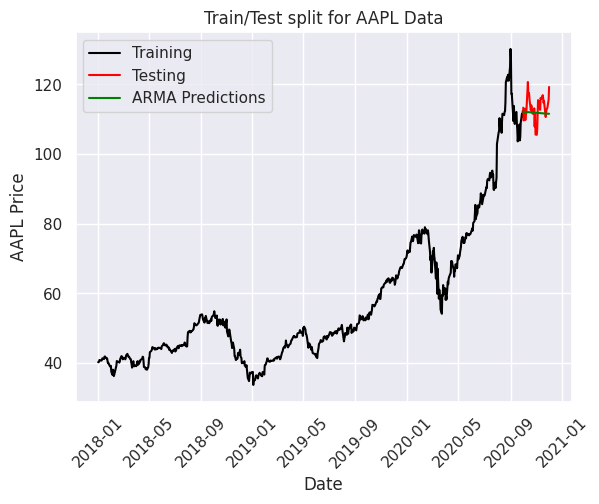

In [ ]:
y = train['Close']

ARMAmodel = SARIMAX(y, order = (1, 0, 1))
ARMAmodel = ARMAmodel.fit()

y_pred = ARMAmodel.get_forecast(len(test.index))
y_pred_df_arma = y_pred.conf_int(alpha = 0.05) 
y_pred_df_arma["Predictions"] = ARMAmodel.predict(start = y_pred_df_arma.index[0], 
                                                   end = y_pred_df_arma.index[-1])
y_pred_df_arma.index = test.index
y_pred_outARMA = y_pred_df_arma["Predictions"] 

plt.plot(train, color = "black", label = 'Training')
plt.plot(test, color = "red", label = 'Testing')
plt.ylabel('AAPL Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for AAPL Data")
plt.plot(y_pred_outARMA, color='green', label = 'ARMA Predictions')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

arma_rmse = np.sqrt(mean_squared_error(test["Close"].values, y_pred_df_arma["Predictions"]))
print("ARMA RMSE: ",arma_rmse)

ARMA RMSE:  3.5837310024552544


In [ ]:
#ARIMAmodel = SARIMAX(y, order = (2, 2, 2))
#ARIMAmodel = SARIMAX(y, order = (2, 3, 2))
ARIMAmodel = SARIMAX(y, order = (5, 4, 2))
ARIMAmodel = ARIMAmodel.fit()

y_pred = ARIMAmodel.get_forecast(len(test.index))
y_pred_df_arima = y_pred.conf_int(alpha = 0.05) 
y_pred_df_arima["Predictions"] = ARIMAmodel.predict(start = y_pred_df_arima.index[0],
                                                     end = y_pred_df_arima.index[-1])
y_pred_df_arima.index = test.index
y_pred_outARIMA = y_pred_df_arima["Predictions"]

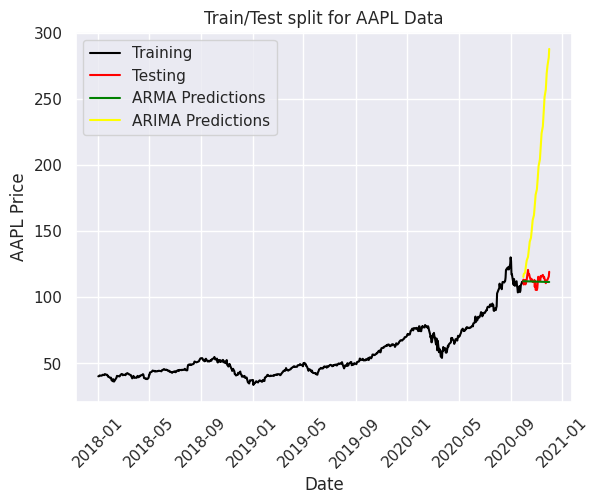

In [ ]:
plt.plot(train, color = "black", label = 'Training')
plt.plot(test, color = "red", label = 'Testing')
plt.ylabel('AAPL Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for AAPL Data")
plt.plot(y_pred_outARMA, color='green', label = 'ARMA Predictions')
plt.plot(y_pred_outARIMA, color='Yellow', label = 'ARIMA Predictions')
plt.legend()
plt.show()

In [ ]:
arima_rmse = np.sqrt(mean_squared_error(test["Close"].values, y_pred_df_arima["Predictions"]))
print("ARIMA RMSE: ",arima_rmse)

ARIMA RMSE:  88.67140734146768


In [ ]:
SARIMAXmodel = SARIMAX(y, order = (2,2,2), seasonal_order=(2,2,2,12))
SARIMAXmodel = SARIMAXmodel.fit()

y_pred = SARIMAXmodel.get_forecast(len(test.index))
y_pred_df_sarima = y_pred.conf_int(alpha = 0.05) 
y_pred_df_sarima["Predictions"] = SARIMAXmodel.predict(start = y_pred_df_sarima.index[0],
                                                       end = y_pred_df_sarima.index[-1])
y_pred_df_sarima.index = test.index
y_pred_outSARIMAX = y_pred_df_sarima["Predictions"] 

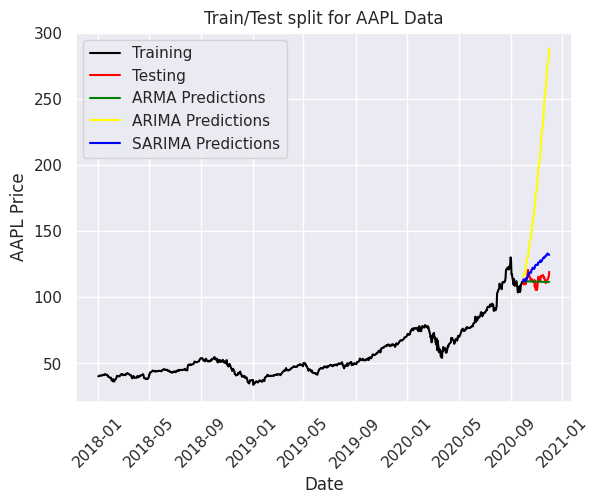

In [ ]:
plt.plot(train, color = "black", label = 'Training')
plt.plot(test, color = "red", label = 'Testing')
plt.ylabel('AAPL Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test split for AAPL Data")
plt.plot(y_pred_outARMA, color='green', label = 'ARMA Predictions')
plt.plot(y_pred_outARIMA, color='Yellow', label = 'ARIMA Predictions')
plt.plot(y_pred_outSARIMAX, color='Blue', label = 'SARIMA Predictions')
plt.legend()
plt.show()

In [ ]:
sarima_rmse = np.sqrt(mean_squared_error(test["Close"].values, y_pred_df_sarima["Predictions"]))
print("SARIMA RMSE: ",sarima_rmse)

SARIMA RMSE:  12.026443334610661


In [ ]:
arma_rmse = np.sqrt(
    mean_squared_error(
        test["Close"].values,
        y_pred_df_arma["Predictions"]
    )
)

print("ARMA RMSE:", arma_rmse)

ARMA RMSE: 3.5837310024552544


In [ ]:
arima_rmse = np.sqrt(
    mean_squared_error(
        test["Close"].values,
        y_pred_df_arima["Predictions"]
    )
)

print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 88.67140734146768


In [ ]:
sarima_rmse = np.sqrt(
    mean_squared_error(
        test["Close"].values,
        y_pred_df_sarima["Predictions"]
    )
)

print("SARIMA RMSE:", sarima_rmse)

SARIMA RMSE: 12.026443334610661


In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["ARMA", "ARIMA", "SARIMA"],
    "RMSE": [arma_rmse, arima_rmse, sarima_rmse]
})

model_comparison

,Model,RMSE
0,ARMA,3.583731
1,ARIMA,88.671407
2,SARIMA,12.026443


# Neural Network Forecasting using Tweets and Financial Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')
training_data1 = df.copy()

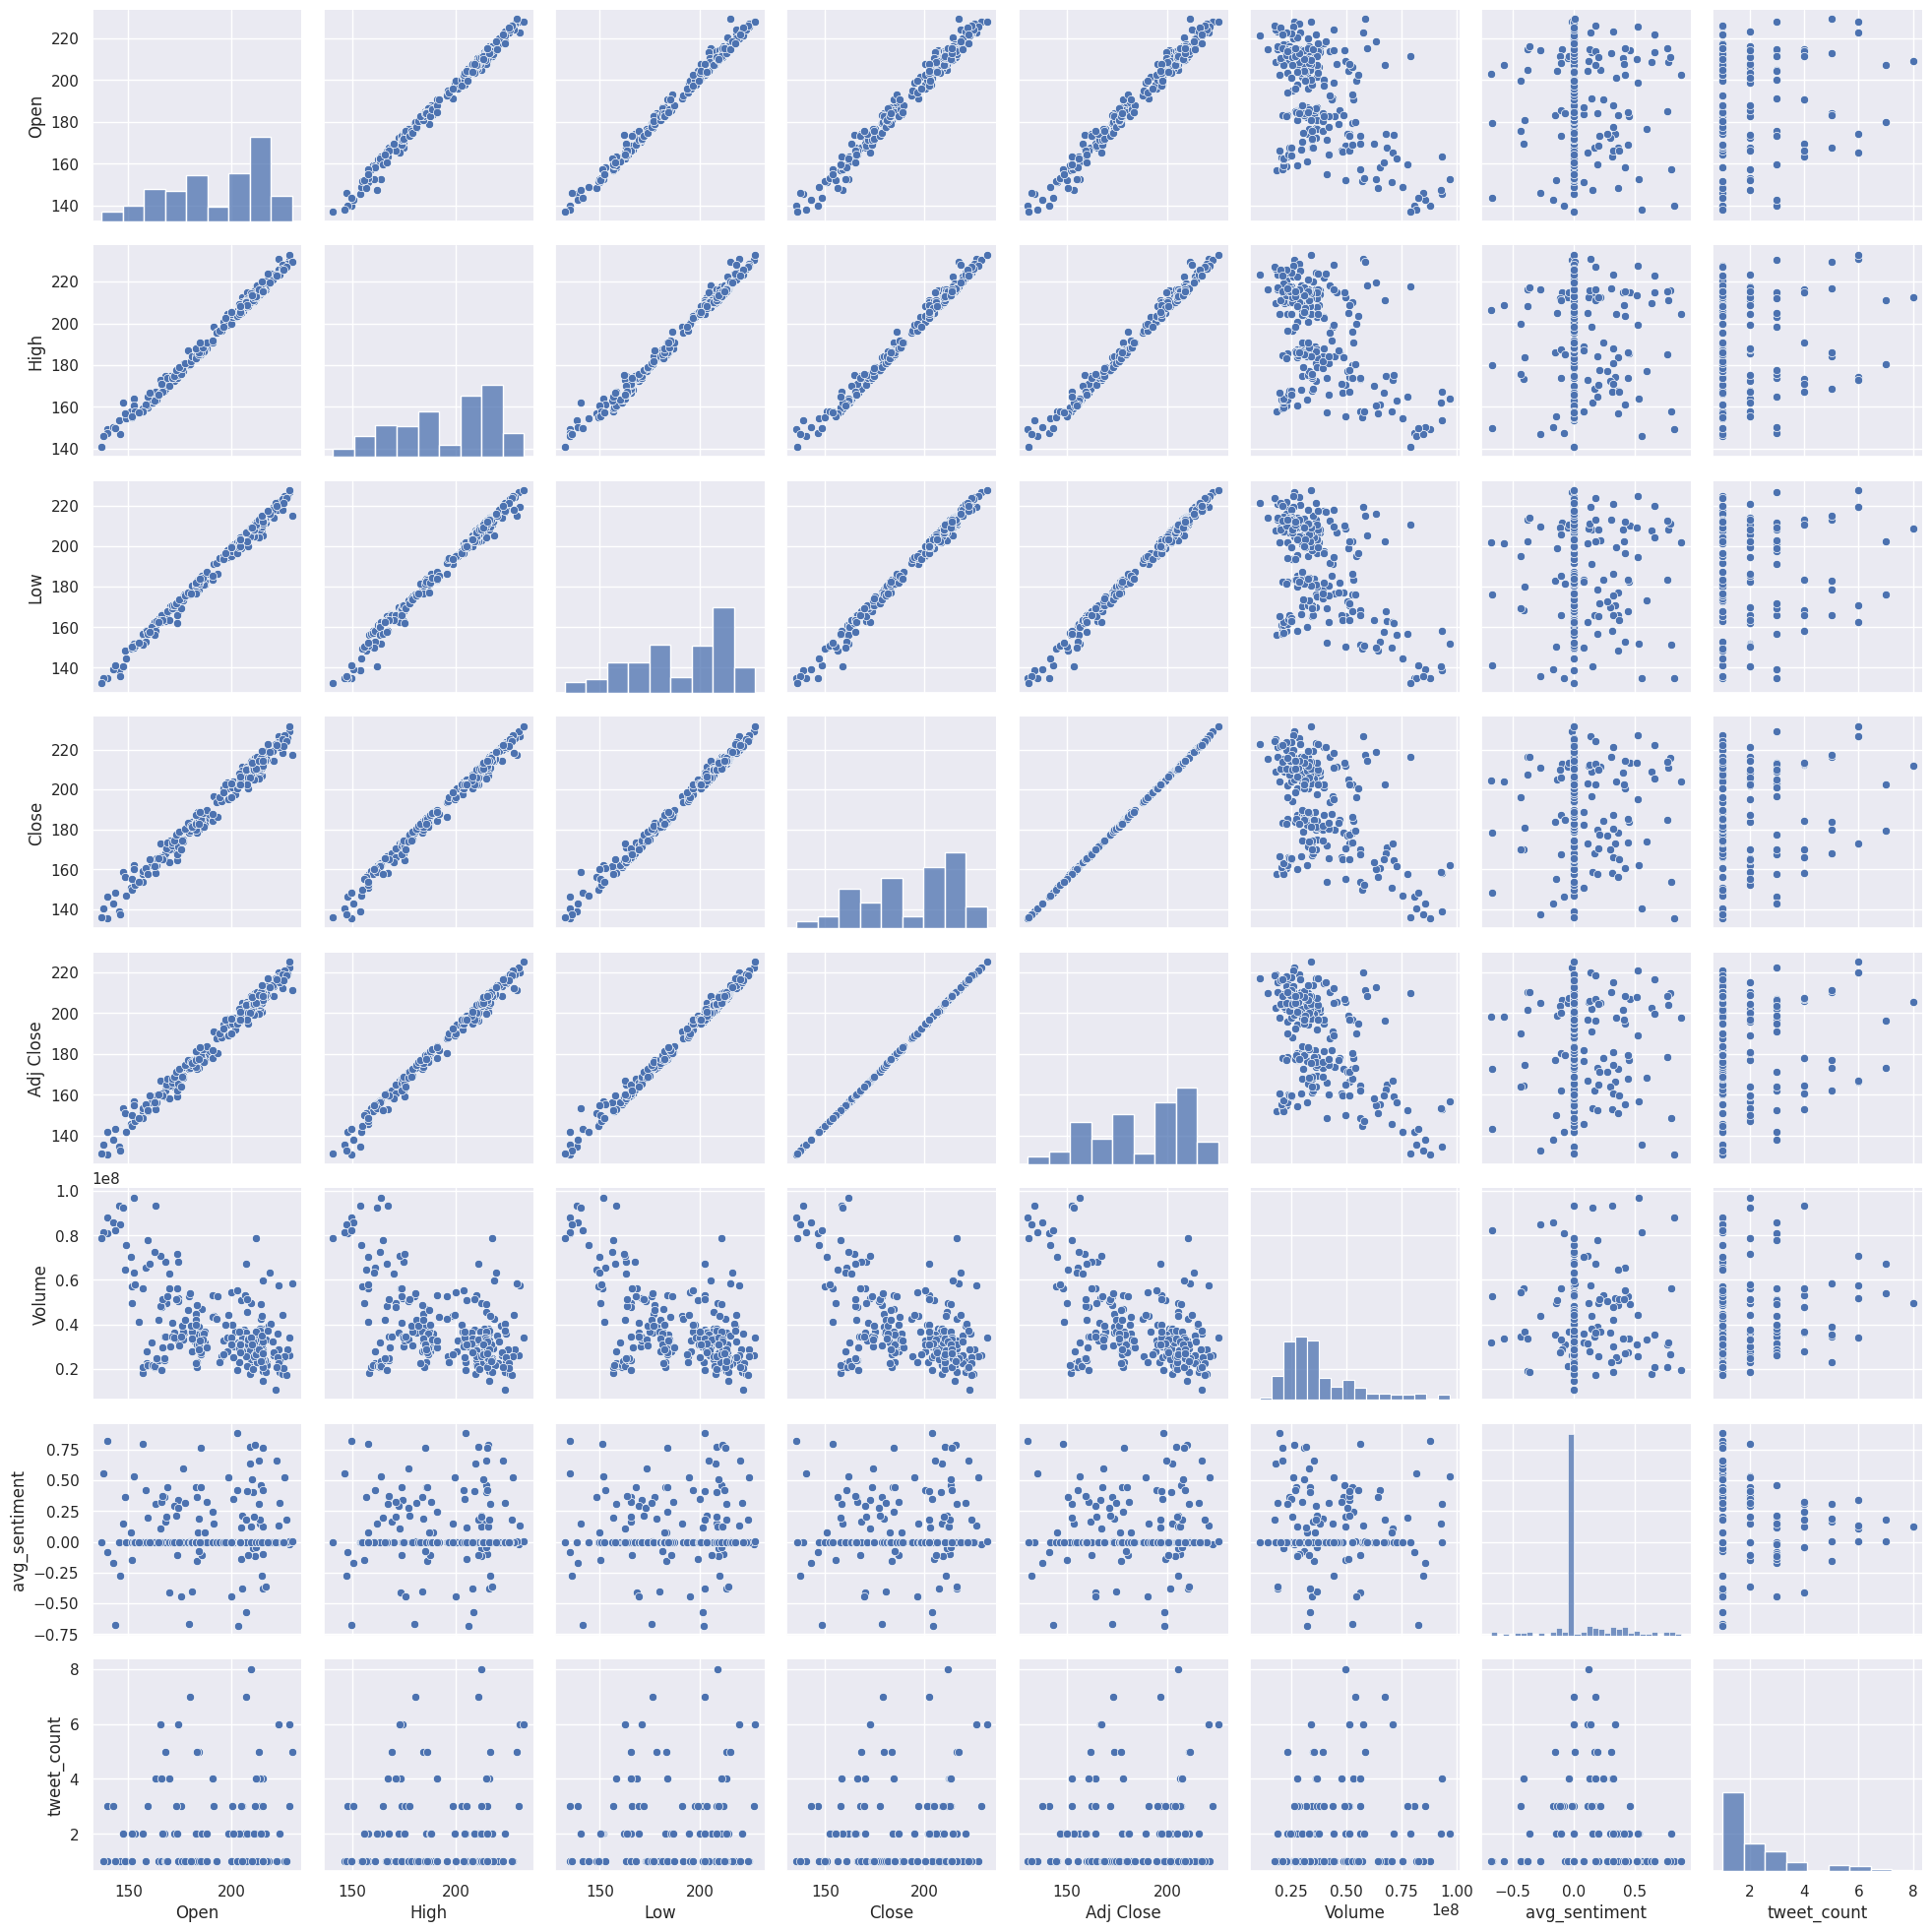

In [ ]:
sns.pairplot(training_data1)

In [ ]:
df = pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv')

close_data = df[['Close']].values

train_size = int(len(close_data) * 0.8)

training_data = close_data[:train_size]
test_data = close_data[train_size:]

print(training_data.shape)
print(test_data.shape)

(203, 1)
(51, 1)


In [ ]:
type(training_data)

numpy.ndarray

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
training_data = scaler.fit_transform(training_data.reshape(-1, 1))

In [ ]:
x_training_data = []

y_training_data =[]

In [ ]:
for i in range(40, len(training_data)):
    x_training_data.append(training_data[i-40:i, 0])
    y_training_data.append(training_data[i, 0])

In [ ]:
x_training_data = np.array(x_training_data)

y_training_data = np.array(y_training_data)

In [ ]:
print(x_training_data.shape)

print(y_training_data.shape)

(163, 40)
(163,)


In [ ]:
x_training_data = np.reshape(x_training_data, (x_training_data.shape[0], 

                                               x_training_data.shape[1], 

                                               1))

In [ ]:
print(x_training_data.shape)

(163, 40, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

In [ ]:
rnn = Sequential()

In [ ]:
rnn.add(LSTM(units = 45, return_sequences = True, input_shape = (x_training_data.shape[1], 1)))

In [ ]:
rnn.add(Dropout(0.2))

In [ ]:
rnn.add(LSTM(units = 45, return_sequences = True))

rnn.add(Dropout(0.2))

rnn.add(LSTM(units = 45, return_sequences = True))

rnn.add(Dropout(0.2))

rnn.add(LSTM(units = 45))

rnn.add(Dropout(0.2))

In [ ]:
rnn.add(Dense(units = 1))

In [ ]:
rnn.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [ ]:
rnn.fit(x_training_data, y_training_data, epochs = 50, batch_size = 16)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.1923
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0492
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0389
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0289
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0275
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0229
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0220
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0216
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0209
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0216
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0194
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0216
Epoch 13/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0219
Epoch 14/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0163
Epoch 15/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0171
Epoc

In [ ]:
print(test_data.shape)

(51, 1)


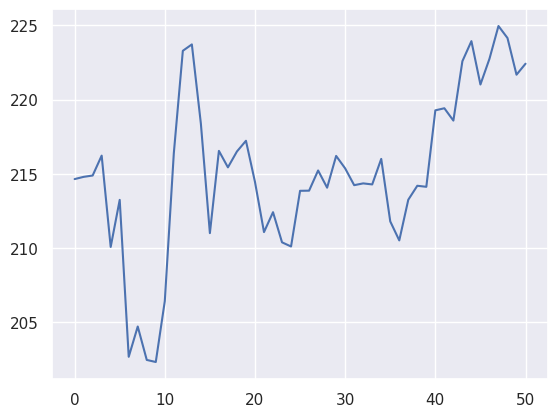

In [ ]:
plt.plot(test_data)

In [ ]:
all_close_data = df[['Close']].values

inputs = all_close_data[len(all_close_data) - len(test_data) - 40:]

inputs = scaler.transform(inputs)

In [ ]:
x_test_data = []

for i in range(40, len(inputs)):
    x_test_data.append(inputs[i-40:i, 0])

x_test_data = np.array(x_test_data)

x_test_data = np.reshape(
    x_test_data,
    (x_test_data.shape[0], x_test_data.shape[1], 1)
)

In [ ]:
x_test_data = np.reshape(x_test_data, (x_test_data.shape[0], x_test_data.shape[1],1))

In [ ]:
predictions = rnn.predict(x_test_data)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step


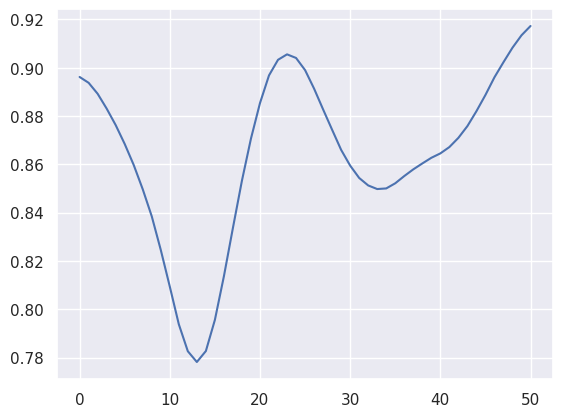

In [ ]:
plt.plot(predictions) 

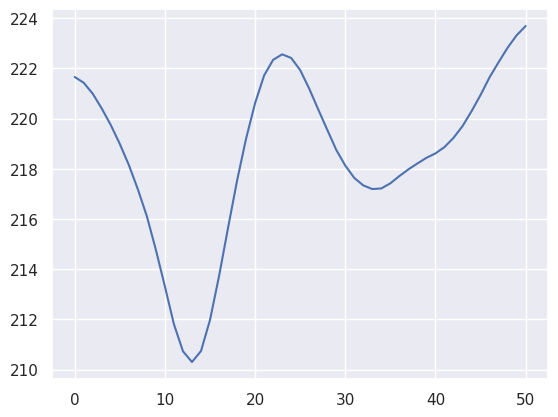

In [ ]:
unscaled_predictions = scaler.inverse_transform(predictions)

plt.plot(unscaled_predictions)


In [ ]:
real_data = scaler.inverse_transform(test_data.reshape(-1, 1))

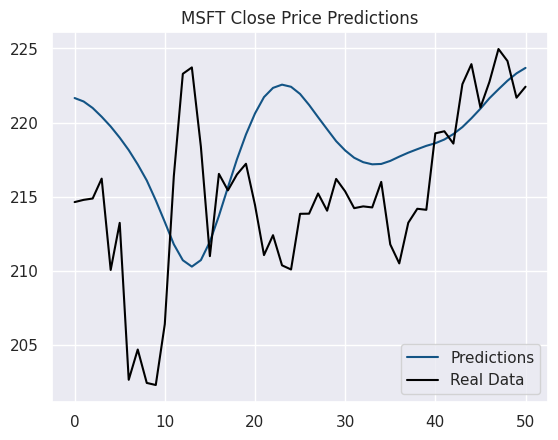

In [ ]:
plt.plot(unscaled_predictions, color = '#135485', label = "Predictions")

plt.plot(test_data, color = 'black', label = "Real Data")

plt.title('MSFT Close Price Predictions')

plt.legend()

In [ ]:
print("The first trading day prediction is: ",unscaled_predictions[0])
print("The real first trading day price is: ",test_data[0])

The first trading day prediction is:  [221.65814]
The real first trading day price is:  [214.6499939]


In [ ]:
print("The last trading day prediction is: ", unscaled_predictions[20])
print("The real last trading day price is: ", test_data[20])

The last trading day prediction is:  [220.61688]
The real last trading day price is:  [214.46000671]


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

lstm_rmse = np.sqrt(mean_squared_error(test_data, unscaled_predictions))

print("LSTM RMSE:", lstm_rmse)

LSTM RMSE: 6.908425558026705


In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["ARMA", "ARIMA", "SARIMA", "LSTM"],
    "RMSE": [arma_rmse, arima_rmse, sarima_rmse, lstm_rmse]
})

model_comparison.sort_values("RMSE")

,Model,RMSE
0,ARMA,3.583731
3,LSTM,6.908426
2,SARIMA,12.026443
1,ARIMA,88.671407


## Five_company_model_comparison

In [ ]:
future_forecast = SARIMAXmodel.forecast(steps=5)

print(future_forecast)

692    112.068142
693    113.610930
694    112.964914
695    111.990385
696    114.000561
Name: predicted_mean, dtype: float64


In [ ]:
forecast_table = pd.DataFrame({
    "Horizon": ["1 Day", "3 Day", "5 Day"],
    "Forecast_Close": [
        future_forecast.iloc[0],
        future_forecast.iloc[2],
        future_forecast.iloc[4]
    ]
})

forecast_table

,Horizon,Forecast_Close
0,1 Day,112.068142
1,3 Day,112.964914
2,5 Day,114.000561


In [ ]:
print(df['Close'].min(), df['Close'].max())

135.4199981689453 231.6499938964844


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

company_files = {
    "AAPL": "/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv",
    "AMZN": "/home/chakuunaa/BD_ADA_CA2sem2/data/amzn_features.csv",
    "GOOG": "/home/chakuunaa/BD_ADA_CA2sem2/data/goog_features.csv",
    "TSLA": "/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv",
    "MSFT": "/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv"
}

results_list = []

for company, path in company_files.items():

    df = pd.read_csv(path, parse_dates=["Date"])
    close = df["Close"].dropna()

    train_size = int(len(close) * 0.8)
    train = close[:train_size]
    test = close[train_size:]

    # ARMA
    arma_model = SARIMAX(train, order=(1, 0, 1))
    arma_fit = arma_model.fit(disp=False)
    arma_pred = arma_fit.forecast(steps=len(test))
    arma_rmse = np.sqrt(mean_squared_error(test, arma_pred))

    # ARIMA
    arima_model = SARIMAX(train, order=(5, 4, 2))
    arima_fit = arima_model.fit(disp=False)
    arima_pred = arima_fit.forecast(steps=len(test))
    arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))

    # SARIMA
    sarima_model = SARIMAX(
        train,
        order=(2, 2, 2),
        seasonal_order=(2, 2, 2, 12)
    )
    sarima_fit = sarima_model.fit(disp=False)
    sarima_pred = sarima_fit.forecast(steps=len(test))
    sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))

    best_model = min(
        {
            "ARMA": arma_rmse,
            "ARIMA": arima_rmse,
            "SARIMA": sarima_rmse
        },
        key={
            "ARMA": arma_rmse,
            "ARIMA": arima_rmse,
            "SARIMA": sarima_rmse
        }.get
    )

    results_list.append({
        "Company": company,
        "ARMA_RMSE": arma_rmse,
        "ARIMA_RMSE": arima_rmse,
        "SARIMA_RMSE": sarima_rmse,
        "Best_Model": best_model
    })

forecast_model_results = pd.DataFrame(results_list)

forecast_model_results

,Company,ARMA_RMSE,ARIMA_RMSE,SARIMA_RMSE,Best_Model
0,AAPL,8.841963,723.316948,10.905604,ARMA
1,AMZN,3.906138,913.568036,23.010568,ARMA
2,GOOG,10.446024,348.254989,5.189807,SARIMA
3,TSLA,52.898886,1260.941587,32.146837,SARIMA
4,MSFT,5.773540,920.600871,12.031416,ARMA


In [ ]:
forecast_model_results.to_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/five_company_model_comparison.csv",
    index=False
)

## 1, 3, 5 Day Forecast for Five Companies

In [ ]:
forecast_rows = []

for company, path in company_files.items():

    df = pd.read_csv(path, parse_dates=["Date"])
    close = df["Close"].dropna()

    train_size = int(len(close) * 0.8)
    train = close[:train_size]

    # Best model from previous table
    best_model = forecast_model_results.loc[
        forecast_model_results["Company"] == company,
        "Best_Model"
    ].values[0]

    if best_model == "ARMA":
        model = SARIMAX(train, order=(1, 0, 1))

    elif best_model == "ARIMA":
        model = SARIMAX(train, order=(5, 4, 2))

    else:
        model = SARIMAX(
            train,
            order=(2, 2, 2),
            seasonal_order=(2, 2, 2, 12)
        )

    fitted_model = model.fit(disp=False)

    forecast = fitted_model.forecast(steps=5)

    forecast_rows.append({
        "Company": company,
        "Best_Model": best_model,
        "1_Day_Forecast": forecast.iloc[0],
        "3_Day_Forecast": forecast.iloc[2],
        "5_Day_Forecast": forecast.iloc[4]
    })

five_company_forecast = pd.DataFrame(forecast_rows)

five_company_forecast

,Company,Best_Model,1_Day_Forecast,3_Day_Forecast,5_Day_Forecast
0,AAPL,ARMA,116.455934,116.395408,116.334914
1,AMZN,ARMA,160.688211,160.612314,160.536453
2,GOOG,SARIMA,77.028530,77.191502,77.553552
3,TSLA,SARIMA,143.859456,149.355780,147.596504
4,MSFT,ARMA,215.877724,215.811898,215.746092


In [ ]:
five_company_forecast.to_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/five_company_forecast_1_3_5_days.csv",
    index=False
)

# Dynamic Dashboard

In [ ]:
#Data_load 

import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

forecast = pd.read_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/five_company_forecast_1_3_5_days.csv"
)

model = pd.read_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/five_company_model_comparison.csv"
)

forecast.head()

,Company,Best_Model,1_Day_Forecast,3_Day_Forecast,5_Day_Forecast
0,AAPL,ARMA,116.455934,116.395408,116.334914
1,AMZN,ARMA,160.688211,160.612314,160.536453
2,GOOG,SARIMA,77.028530,77.191502,77.553552
3,TSLA,SARIMA,143.859456,149.355780,147.596504
4,MSFT,ARMA,215.877724,215.811898,215.746092


In [ ]:
#Interactive dashboard

def stock_dashboard(company):
    selected_forecast = forecast[forecast["Company"] == company]
    selected_model = model[model["Company"] == company]

    display(selected_forecast)
    display(selected_model)

    horizons = ["1 Day", "3 Day", "5 Day"]
    values = [
        selected_forecast["1_Day_Forecast"].iloc[0],
        selected_forecast["3_Day_Forecast"].iloc[0],
        selected_forecast["5_Day_Forecast"].iloc[0]
    ]

    plt.figure(figsize=(8, 5))
    plt.bar(horizons, values)
    plt.title(f"{company} 1, 3 and 5 Day Forecast")
    plt.ylabel("Forecast Close Price")
    plt.show()

interact(
    stock_dashboard,
    company=widgets.Dropdown(
        options=forecast["Company"].unique(),
        description="Company:"
    )
)

interactive(children=(Dropdown(description='Company:', options=('AAPL', 'AMZN', 'GOOG', 'TSLA', 'MSFT'), value…

<function __main__.stock_dashboard(company)>

2026-05-31 00:18:43.759 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-31 00:18:44.154 
  command:

    streamlit run /home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-05-31 00:18:44.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-31 00:18:44.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-31 00:18:44.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-31 00:18:44.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-31 00:18:44.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-31 00:18:44.1

DeltaGenerator()

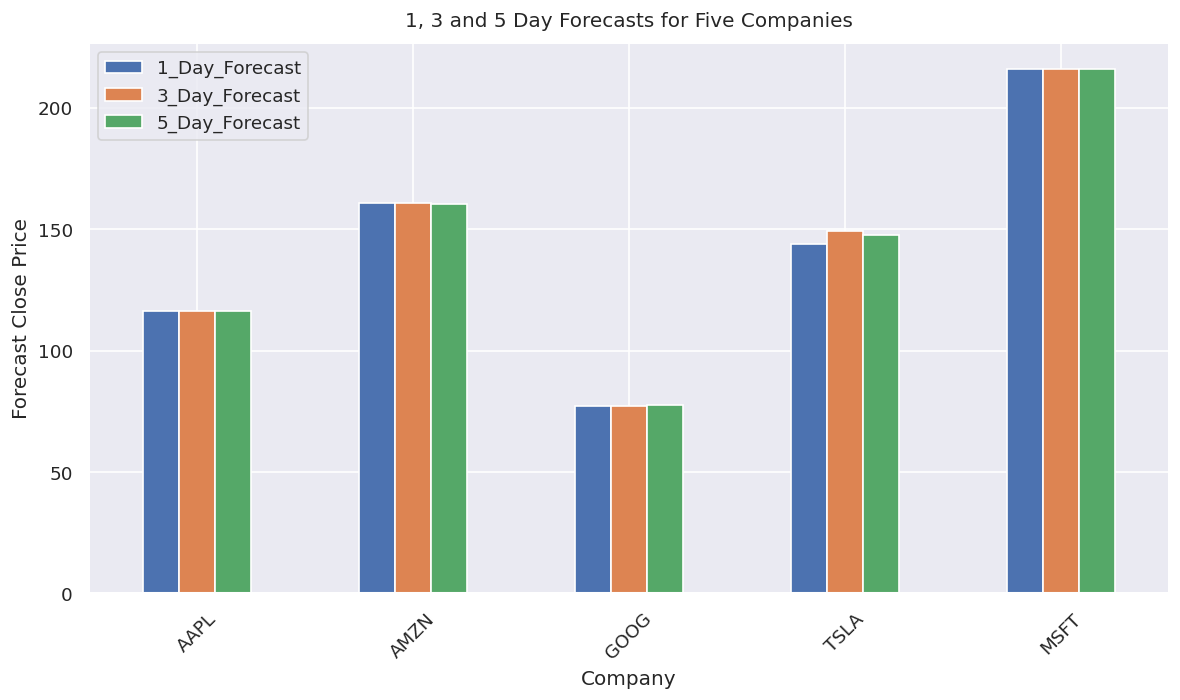

In [ ]:
#Full comparison chart

import streamlit as st
import matplotlib.pyplot as plt
import pandas as pd

st.subheader("Full Comparison Chart")

forecast = pd.read_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/five_company_forecast_1_3_5_days.csv"
)

# Debug check
st.write(forecast.head())
st.write(forecast.columns)

# Numeric болгох
forecast["1_Day_Forecast"] = pd.to_numeric(forecast["1_Day_Forecast"], errors="coerce")
forecast["3_Day_Forecast"] = pd.to_numeric(forecast["3_Day_Forecast"], errors="coerce")
forecast["5_Day_Forecast"] = pd.to_numeric(forecast["5_Day_Forecast"], errors="coerce")

forecast = forecast.dropna(subset=[
    "Company",
    "1_Day_Forecast",
    "3_Day_Forecast",
    "5_Day_Forecast"
])

fig, ax = plt.subplots(figsize=(10, 6))

forecast.set_index("Company")[[
    "1_Day_Forecast",
    "3_Day_Forecast",
    "5_Day_Forecast"
]].plot(kind="bar", ax=ax)

ax.set_title("1, 3 and 5 Day Forecasts for Five Companies")
ax.set_ylabel("Forecast Close Price")
ax.set_xlabel("Company")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

st.pyplot(fig)

In [ ]:
#Best model summary

best_model_summary = model[["Company", "Best_Model"]]
display(best_model_summary)

,Company,Best_Model
0,AAPL,ARMA
1,AMZN,ARMA
2,GOOG,SARIMA
3,TSLA,SARIMA
4,MSFT,ARMA


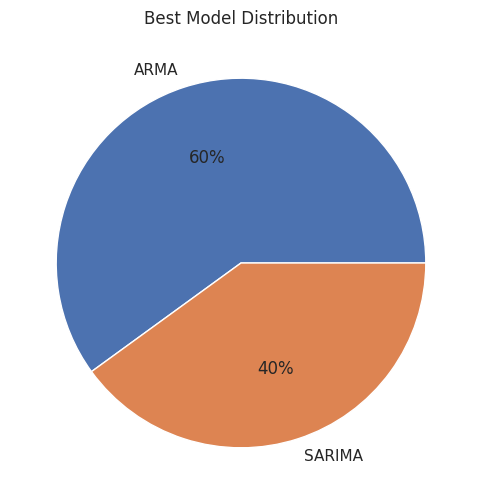

In [ ]:
best_model_count = model["Best_Model"].value_counts()

best_model_count.plot(
    kind="pie",
    autopct="%1.0f%%",
    figsize=(6,6)
)

plt.title("Best Model Distribution")
plt.ylabel("")
plt.show()